# **Student Performance Prediction Using Machine Learning**
## **Complete Pipeline — EDA + Feature Engineering + Modelling**

**Module:** 7PAM2002 Data Science Project  
**Student:** Papitha Ravichandran (24078677)  
**University of Hertfordshire — MSc Data Science**  
**Dataset:** Open University Learning Analytics Dataset (OULAD)

---

This single notebook contains both parts combined into one file:

- **PART A — Exploratory Data Analysis (EDA)**
- **PART B — Feature Engineering, Modelling, SHAP, Temporal Validation**

It addresses all three research questions:

- **RQ1:** Predictive accuracy under multi-class imbalance  
- **RQ2:** Feature importance and explainability for early intervention  
- **RQ3:** Generalisability and temporal stability across cohorts

---
# **PART A — Exploratory Data Analysis (EDA)**
---

## **Step 1 — Import Libraries (Unified)**

All libraries used across both the EDA and Modelling sections are imported here in a single cell.

In [1]:
# =============================================================
# UNIFIED IMPORTS — all libraries used across EDA + Modelling
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import time

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             accuracy_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# Gradient boosting and explainability
import xgboost as xgb
import lightgbm as lgb
import shap

# Statistics
from scipy.stats import spearmanr

# Global display settings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## **Step 2 — Load All OULAD Tables**

In [2]:
DATA_DIR = 'dataset/'

courses       = pd.read_csv(DATA_DIR + 'courses.csv')
assessments   = pd.read_csv(DATA_DIR + 'assessments.csv')
student_info  = pd.read_csv(DATA_DIR + 'studentInfo.csv')
student_reg   = pd.read_csv(DATA_DIR + 'studentRegistration.csv')
student_assess = pd.read_csv(DATA_DIR + 'studentAssessment.csv')
vle           = pd.read_csv(DATA_DIR + 'vle.csv')

tables = {
    'courses': courses, 'assessments': assessments,
    'studentInfo': student_info, 'studentRegistration': student_reg,
    'studentAssessment': student_assess, 'vle': vle
}

print("Table shapes:")
for name, df in tables.items():
    print(f"  {name:25s} {str(df.shape):>15s}  cols: {df.columns.tolist()}")

Table shapes:
  courses                           (22, 3)  cols: ['code_module', 'code_presentation', 'module_presentation_length']
  assessments                      (206, 6)  cols: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
  studentInfo                   (32593, 12)  cols: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
  studentRegistration            (32593, 5)  cols: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']
  studentAssessment             (173912, 5)  cols: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
  vle                             (6364, 6)  cols: ['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to']


## **Step 3 — Data Overview and Schema**

The OULAD consists of 7 relational tables linked by `code_module`, `code_presentation`, `id_student`, `id_assessment`, and `id_site`. The central table is `studentInfo` which contains the target variable `final_result` with four classes: Distinction, Pass, Fail, and Withdrawn.

In [3]:
print("=== studentInfo — first 5 rows ===")
print(student_info.head().to_string())
print("\n=== Data types ===")
print(student_info.dtypes)
print("\n=== Basic statistics (numeric columns) ===")
print(student_info.describe().to_string())

=== studentInfo — first 5 rows ===
  code_module code_presentation  id_student gender                region      highest_education imd_band age_band  num_of_prev_attempts  studied_credits disability final_result
0         AAA             2013J       11391      M   East Anglian Region       HE Qualification  90-100%     55<=                     0              240          N         Pass
1         AAA             2013J       28400      F              Scotland       HE Qualification   20-30%    35-55                     0               60          N         Pass
2         AAA             2013J       30268      F  North Western Region  A Level or Equivalent   30-40%    35-55                     0               60          Y    Withdrawn
3         AAA             2013J       31604      F     South East Region  A Level or Equivalent   50-60%    35-55                     0               60          N         Pass
4         AAA             2013J       32885      F  West Midlands Region     Low

## **Step 4 — Missing Value Analysis**

In [4]:
print("=== Missing values per table ===\n")
for name, df in tables.items():
    total = df.isnull().sum()
    missing = total[total > 0]
    if len(missing) > 0:
        pct = (missing / len(df) * 100).round(1)
        info = pd.DataFrame({'missing_count': missing, 'pct': pct})
        print(f"{name} ({len(df)} rows):")
        print(info.to_string())
        print()
    else:
        print(f"{name}: no missing values\n")

# Specific note on imd_band
print(f"\nimd_band has {student_info['imd_band'].isnull().sum()} missing values ({student_info['imd_band'].isnull().mean()*100:.1f}%)")
print("These likely represent students from outside England where IMD is not applicable.")
print("\ndate_unregistration is NaN for students who did NOT withdraw — this is expected, not an error.")

=== Missing values per table ===

courses: no missing values

assessments (206 rows):
      missing_count  pct
date             11  5.3

studentInfo (32593 rows):
          missing_count  pct
imd_band           1111  3.4

studentRegistration (32593 rows):
                     missing_count   pct
date_registration               45   0.1
date_unregistration          22521  69.1

studentAssessment (173912 rows):
       missing_count  pct
score            173  0.1

vle (6364 rows):
           missing_count   pct
week_from           5243  82.4
week_to             5243  82.4


imd_band has 1111 missing values (3.4%)
These likely represent students from outside England where IMD is not applicable.

date_unregistration is NaN for students who did NOT withdraw — this is expected, not an error.


## **Step 5 — Target Variable Distribution (final_result)**

This is the most critical step for RQ1. Understanding the class distribution reveals the imbalance that will drive our modelling strategy.

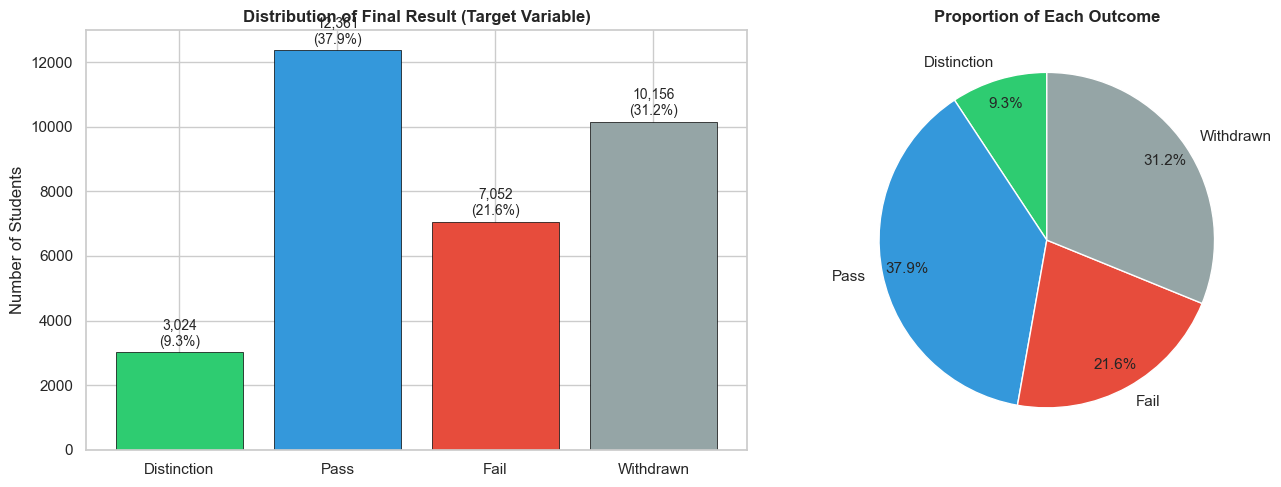


Key finding:
  Pass: 12,361 (37.9%)
  Withdrawn: 10,156 (31.2%)
  Fail: 7,052 (21.6%)
  Distinction: 3,024 (9.3%)

  Pass-to-Distinction ratio: 4.1:1
  (Pass+Withdrawn) vs (Fail+Distinction) = 69.1% vs 30.9%

The dataset is imbalanced — Distinction is the minority class at 9.3%.
SMOTE/ADASYN will be needed to address this for RQ1.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
counts = student_info['final_result'].value_counts().reindex(order)
axes[0].bar(order, counts.values, color=colors, edgecolor='black', linewidth=0.5)
for i, (v, c) in enumerate(zip(counts.values, counts.values)):
    axes[0].text(i, v + 200, f'{c:,}\n({c/len(student_info)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Distribution of Final Result (Target Variable)', fontweight='bold')
axes[0].set_ylabel('Number of Students')

# Pie chart
axes[1].pie(counts.values, labels=order, colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85, wedgeprops=dict(linewidth=1, edgecolor='white'))
axes[1].set_title('Proportion of Each Outcome', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey finding:")
print(f"  Pass: {counts['Pass']:,} ({counts['Pass']/len(student_info)*100:.1f}%)")
print(f"  Withdrawn: {counts['Withdrawn']:,} ({counts['Withdrawn']/len(student_info)*100:.1f}%)")
print(f"  Fail: {counts['Fail']:,} ({counts['Fail']/len(student_info)*100:.1f}%)")
print(f"  Distinction: {counts['Distinction']:,} ({counts['Distinction']/len(student_info)*100:.1f}%)")
print(f"\n  Pass-to-Distinction ratio: {counts['Pass']/counts['Distinction']:.1f}:1")
print(f"  (Pass+Withdrawn) vs (Fail+Distinction) = {(counts['Pass']+counts['Withdrawn'])/len(student_info)*100:.1f}% vs {(counts['Fail']+counts['Distinction'])/len(student_info)*100:.1f}%")
print("\nThe dataset is imbalanced — Distinction is the minority class at 9.3%.")
print("SMOTE/ADASYN will be needed to address this for RQ1.")

## **Step 6 — Demographic Analysis**

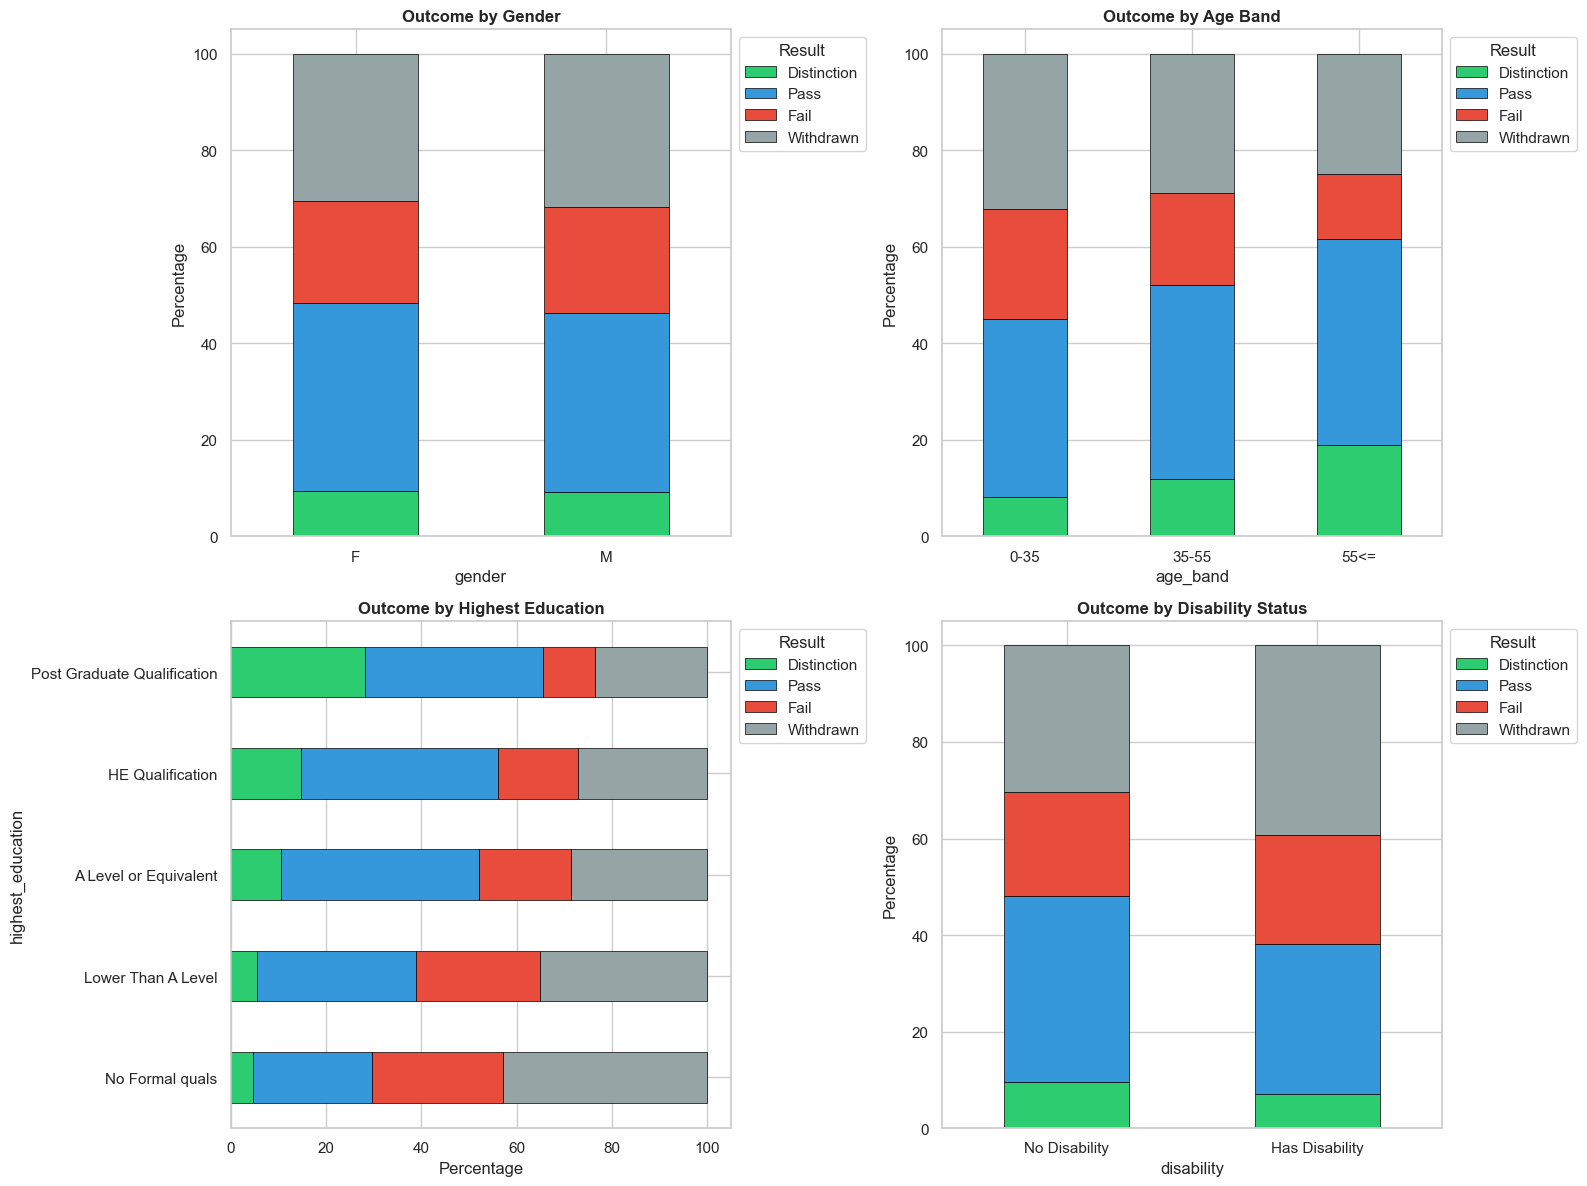

Key demographic findings:
  - Males have slightly higher withdrawal/fail rates than females.
  - Younger students (0-35) form the majority; older students (55+) have higher pass rates.
  - Students with Post Graduate qualifications have the highest Distinction rate.
  - Students with No Formal qualifications have the highest Fail/Withdrawn rate.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender
gender_outcome = pd.crosstab(student_info['gender'], student_info['final_result'], normalize='index').reindex(columns=order) * 100
gender_outcome.plot(kind='bar', stacked=True, color=colors, ax=axes[0, 0], edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Outcome by Gender', fontweight='bold')
axes[0, 0].set_ylabel('Percentage')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].legend(title='Result', bbox_to_anchor=(1.0, 1.0))

# Age band
age_outcome = pd.crosstab(student_info['age_band'], student_info['final_result'], normalize='index').reindex(columns=order) * 100
age_order = ['0-35', '35-55', '55<=']
age_outcome = age_outcome.reindex(age_order)
age_outcome.plot(kind='bar', stacked=True, color=colors, ax=axes[0, 1], edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Outcome by Age Band', fontweight='bold')
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
axes[0, 1].legend(title='Result', bbox_to_anchor=(1.0, 1.0))

# Highest education
edu_outcome = pd.crosstab(student_info['highest_education'], student_info['final_result'], normalize='index').reindex(columns=order) * 100
edu_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent', 'HE Qualification', 'Post Graduate Qualification']
edu_outcome = edu_outcome.reindex(edu_order)
edu_outcome.plot(kind='barh', stacked=True, color=colors, ax=axes[1, 0], edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Outcome by Highest Education', fontweight='bold')
axes[1, 0].set_xlabel('Percentage')
axes[1, 0].legend(title='Result', bbox_to_anchor=(1.0, 1.0))

# Disability
dis_outcome = pd.crosstab(student_info['disability'], student_info['final_result'], normalize='index').reindex(columns=order) * 100
dis_outcome.plot(kind='bar', stacked=True, color=colors, ax=axes[1, 1], edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Outcome by Disability Status', fontweight='bold')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].set_xticklabels(['No Disability', 'Has Disability'], rotation=0)
axes[1, 1].legend(title='Result', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.savefig('demographics_vs_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key demographic findings:")
print("  - Males have slightly higher withdrawal/fail rates than females.")
print("  - Younger students (0-35) form the majority; older students (55+) have higher pass rates.")
print("  - Students with Post Graduate qualifications have the highest Distinction rate.")
print("  - Students with No Formal qualifications have the highest Fail/Withdrawn rate.")

## **Step 7 — Deprivation Index (IMD Band) Analysis**

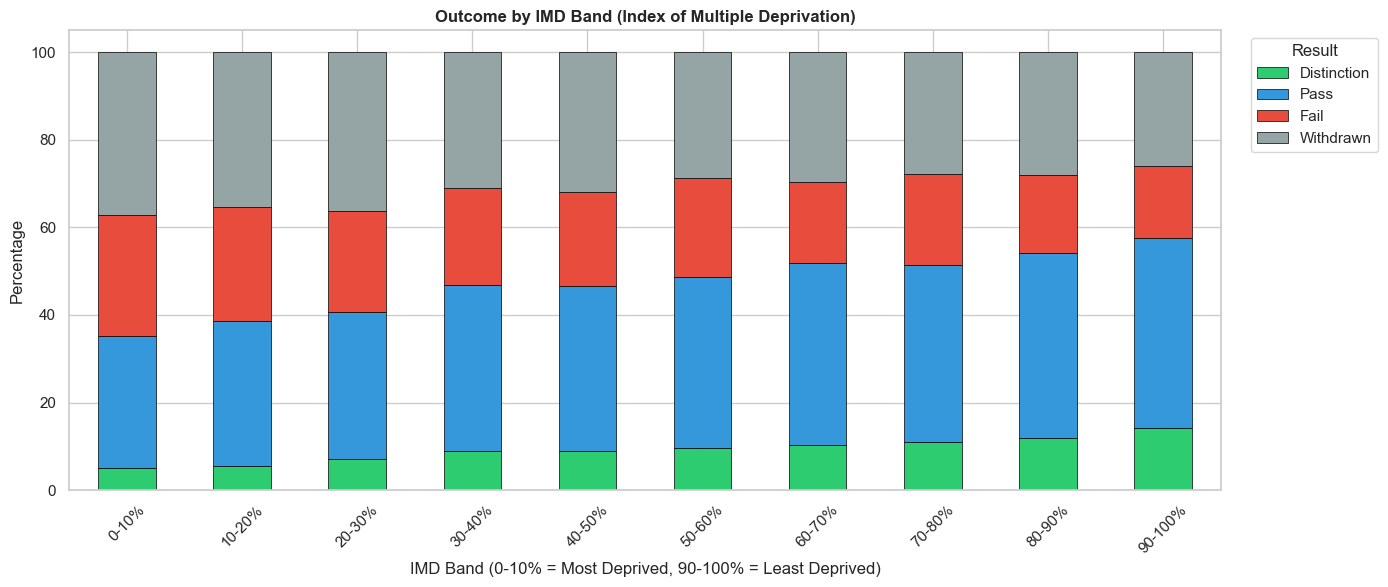

Key finding: Students from more deprived areas (lower IMD) tend to have
higher Fail/Withdrawn rates, suggesting socioeconomic background is a predictor.


In [7]:
imd_data = student_info.dropna(subset=['imd_band']).copy()

# Fix inconsistent labelling
imd_data['imd_band'] = imd_data['imd_band'].replace({'10-20': '10-20%'})

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
imd_outcome = pd.crosstab(imd_data['imd_band'], imd_data['final_result'], normalize='index').reindex(columns=order) * 100
imd_outcome = imd_outcome.reindex(imd_order)

fig, ax = plt.subplots(figsize=(14, 6))
imd_outcome.plot(kind='bar', stacked=True, color=colors, ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Outcome by IMD Band (Index of Multiple Deprivation)', fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xlabel('IMD Band (0-10% = Most Deprived, 90-100% = Least Deprived)')
ax.legend(title='Result', bbox_to_anchor=(1.02, 1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('imd_vs_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key finding: Students from more deprived areas (lower IMD) tend to have")
print("higher Fail/Withdrawn rates, suggesting socioeconomic background is a predictor.")

## **Step 8 — Module and Presentation Analysis (RQ3 relevance)**

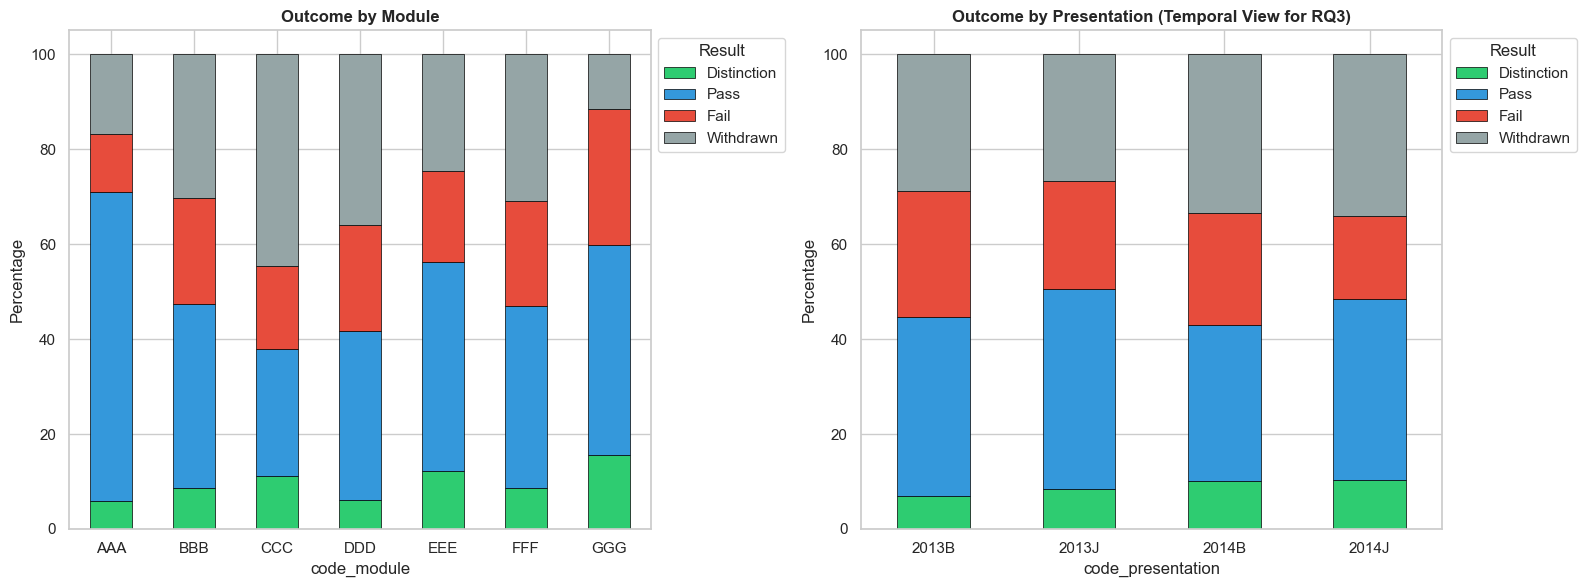

Key findings:
  - Module difficulty varies substantially (e.g., BBB, DDD have higher fail rates).
  - Outcome distributions are relatively stable across presentations (2013B-2014J),
    which is promising for RQ3 — models may generalise across semesters.

Students per presentation:
code_presentation
2013B     4684
2013J     8845
2014B     7804
2014J    11260


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By module
mod_outcome = pd.crosstab(student_info['code_module'], student_info['final_result'], normalize='index').reindex(columns=order) * 100
mod_outcome.plot(kind='bar', stacked=True, color=colors, ax=axes[0], edgecolor='black', linewidth=0.5)
axes[0].set_title('Outcome by Module', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].legend(title='Result', bbox_to_anchor=(1.0, 1.0))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# By presentation (temporal)
pres_outcome = pd.crosstab(student_info['code_presentation'], student_info['final_result'], normalize='index').reindex(columns=order) * 100
pres_order = ['2013B', '2013J', '2014B', '2014J']
pres_outcome = pres_outcome.reindex(pres_order)
pres_outcome.plot(kind='bar', stacked=True, color=colors, ax=axes[1], edgecolor='black', linewidth=0.5)
axes[1].set_title('Outcome by Presentation (Temporal View for RQ3)', fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Result', bbox_to_anchor=(1.0, 1.0))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('module_presentation_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key findings:")
print("  - Module difficulty varies substantially (e.g., BBB, DDD have higher fail rates).")
print("  - Outcome distributions are relatively stable across presentations (2013B-2014J),")
print("    which is promising for RQ3 — models may generalise across semesters.")

# Student counts per presentation
print("\nStudents per presentation:")
print(student_info['code_presentation'].value_counts().sort_index().to_string())

## **Step 9 — Assessment Score Analysis**

Merged assessment records: 173,912
Assessment types: {'TMA': 98426, 'CMA': 70527, 'Exam': 4959}


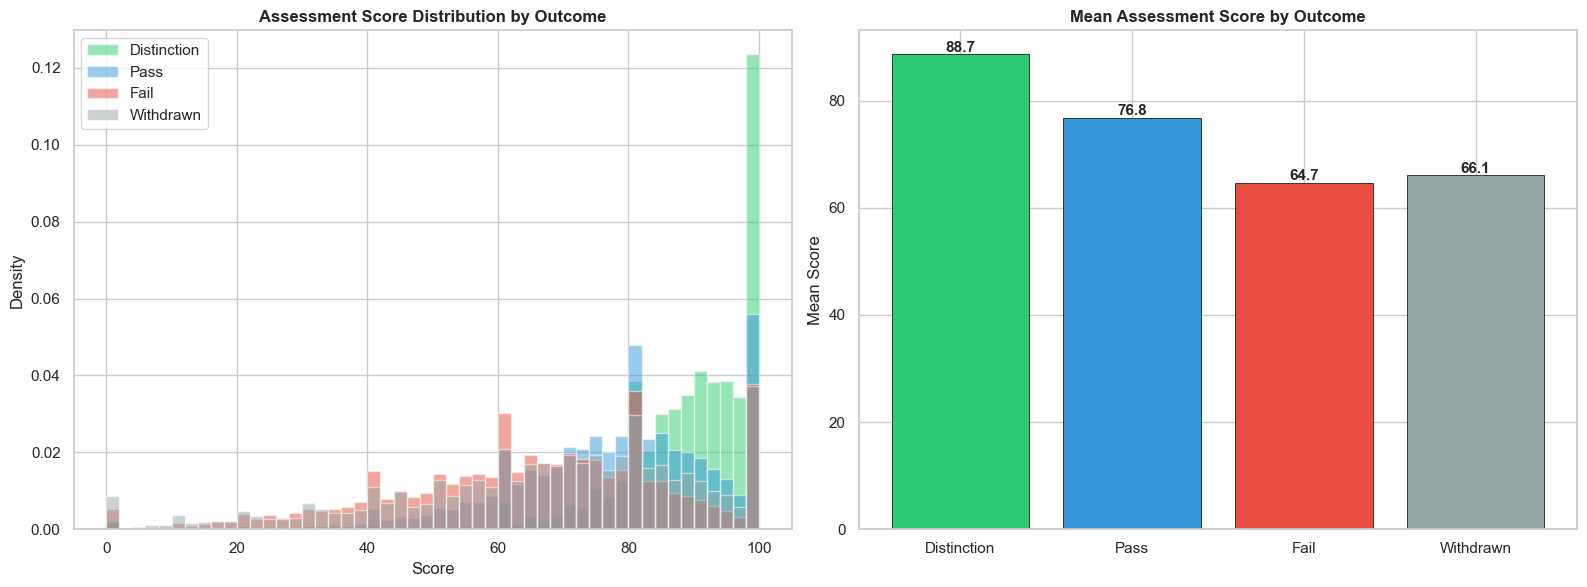


Mean scores: {'Distinction': 88.6829472085074, 'Pass': 76.7707454687839, 'Fail': 64.68520018310504, 'Withdrawn': 66.08492666820241}

Distinction students score ~83 on average vs ~55 for Fail students.
Assessment scores will be a strong predictor feature for RQ2.


In [9]:
# Merge assessment scores with student info
assess_merged = student_assess.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type', 'weight']],
    on='id_assessment', how='left'
)
assess_merged = assess_merged.merge(
    student_info[['code_module', 'code_presentation', 'id_student', 'final_result']],
    on=['code_module', 'code_presentation', 'id_student'], how='left'
)

print(f"Merged assessment records: {len(assess_merged):,}")
print(f"Assessment types: {assess_merged['assessment_type'].value_counts().to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Score distribution by outcome
for result, color in zip(order, colors):
    subset = assess_merged[assess_merged['final_result'] == result]['score'].dropna()
    axes[0].hist(subset, bins=50, alpha=0.5, label=result, color=color, density=True)
axes[0].set_title('Assessment Score Distribution by Outcome', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Average score by outcome
avg_score = assess_merged.groupby('final_result')['score'].mean().reindex(order)
axes[1].bar(order, avg_score.values, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(avg_score.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')
axes[1].set_title('Mean Assessment Score by Outcome', fontweight='bold')
axes[1].set_ylabel('Mean Score')

plt.tight_layout()
plt.savefig('assessment_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean scores: {avg_score.to_dict()}")
print("\nDistinction students score ~83 on average vs ~55 for Fail students.")
print("Assessment scores will be a strong predictor feature for RQ2.")

## **Step 10 — VLE Engagement Analysis**

The `studentVle.csv` file has 10.6 million rows. Rather than loading it entirely into memory, we aggregate clicks per student on-the-fly using chunked reading.

In [10]:
# Aggregate VLE clicks per student using chunked reading
print("Aggregating VLE clicks per student (chunked reading of 10.6M rows)...")

click_agg = pd.DataFrame()
chunk_iter = pd.read_csv(DATA_DIR + 'studentVle.csv', chunksize=500000)

for i, chunk in enumerate(chunk_iter):
    agg = chunk.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].sum().reset_index()
    click_agg = pd.concat([click_agg, agg], ignore_index=True)
    if (i+1) % 5 == 0:
        print(f"  Processed {(i+1)*500000:,} rows...")

# Final aggregation (sum across chunks)
vle_student = click_agg.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].sum().reset_index()
vle_student.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

print(f"\nVLE summary: {len(vle_student):,} student-module records")
print(f"Total clicks range: {vle_student['total_clicks'].min()} - {vle_student['total_clicks'].max():,}")
print(f"Mean clicks: {vle_student['total_clicks'].mean():.0f}, Median: {vle_student['total_clicks'].median():.0f}")

Aggregating VLE clicks per student (chunked reading of 10.6M rows)...


  Processed 2,500,000 rows...


  Processed 5,000,000 rows...


  Processed 7,500,000 rows...


  Processed 10,000,000 rows...



VLE summary: 29,228 student-module records
Total clicks range: 1 - 24,139
Mean clicks: 1355, Median: 740


## **Step 11 — VLE Engagement vs Outcome**

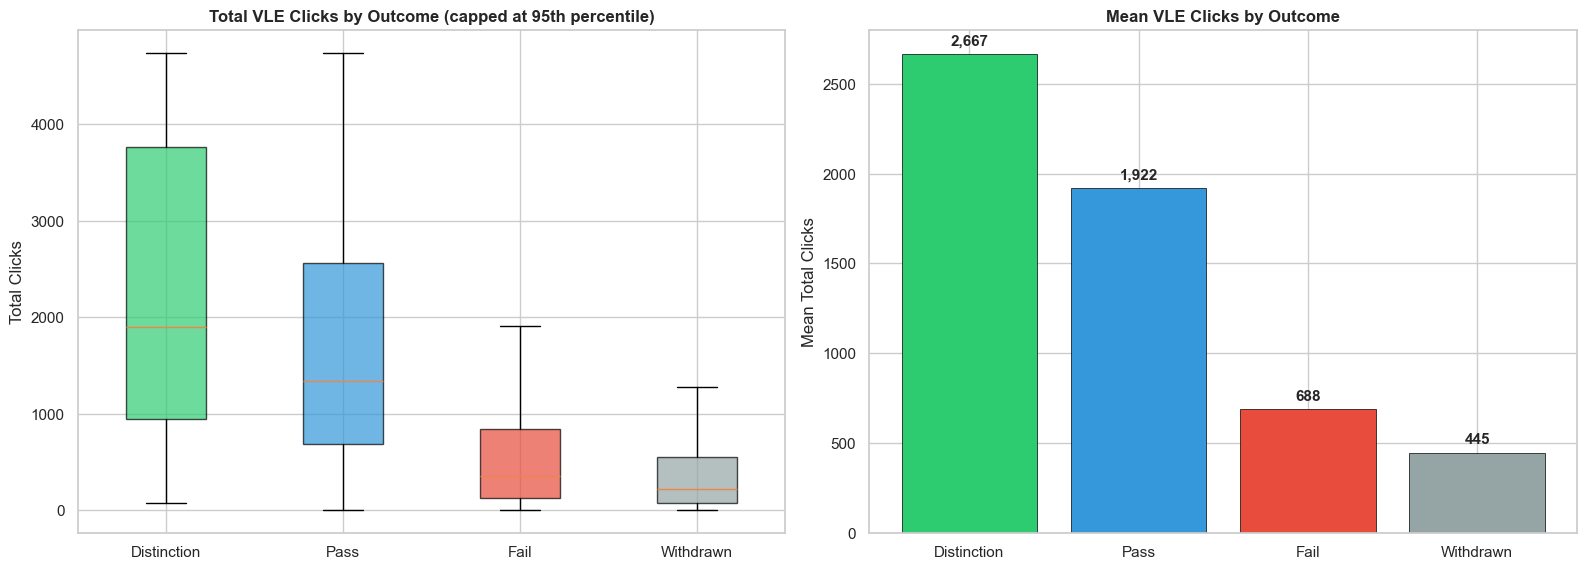

Key finding: Distinction students engage ~2-3x more with VLE than Withdrawn students.
VLE engagement (total clicks) will be a critical feature for RQ1 and RQ2.


In [11]:
# Merge with student info
vle_outcome = vle_student.merge(
    student_info[['code_module', 'code_presentation', 'id_student', 'final_result']],
    on=['code_module', 'code_presentation', 'id_student'], how='inner'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot (95th-percentile capped for readability)
bp_data = [vle_outcome[vle_outcome['final_result'] == r]['total_clicks'].clip(upper=vle_outcome['total_clicks'].quantile(0.95)) for r in order]
bp = axes[0].boxplot(bp_data, labels=order, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Total VLE Clicks by Outcome (capped at 95th percentile)', fontweight='bold')
axes[0].set_ylabel('Total Clicks')

# Mean clicks bar
mean_clicks = vle_outcome.groupby('final_result')['total_clicks'].mean().reindex(order)
axes[1].bar(order, mean_clicks.values, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(mean_clicks.values):
    axes[1].text(i, v + 50, f'{v:,.0f}', ha='center', fontweight='bold')
axes[1].set_title('Mean VLE Clicks by Outcome', fontweight='bold')
axes[1].set_ylabel('Mean Total Clicks')

plt.suptitle('')
plt.tight_layout()
plt.savefig('vle_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key finding: Distinction students engage ~2-3x more with VLE than Withdrawn students.")
print("VLE engagement (total clicks) will be a critical feature for RQ1 and RQ2.")

## **Step 12 — VLE Activity Type Breakdown**

Aggregating VLE activity types per student...



Top 10 VLE activity types by total clicks:
activity_type
oucontent        11206803
forumng           7973390
quiz              6981240
homepage          6949064
subpage           3411582
resource          1110132
ouwiki             894512
url                566702
oucollaborate      108974
glossary            87962


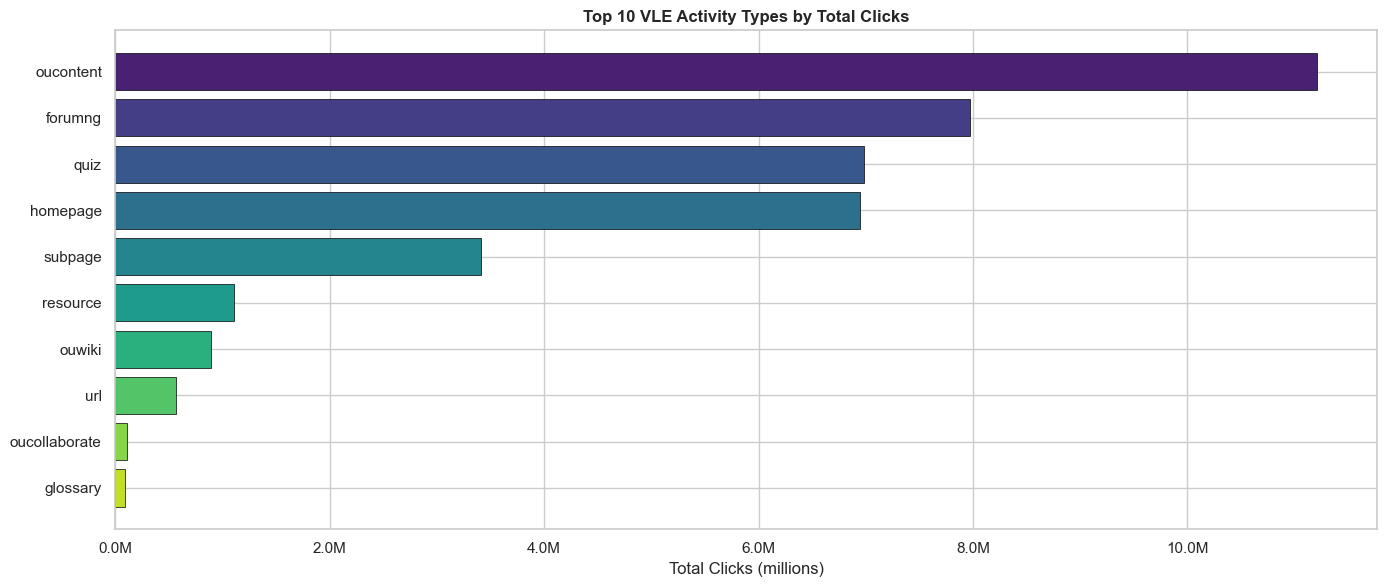

In [12]:
# Aggregate by activity type per student
print("Aggregating VLE activity types per student...")

activity_agg = pd.DataFrame()
chunk_iter = pd.read_csv(DATA_DIR + 'studentVle.csv', chunksize=500000)

for chunk in chunk_iter:
    chunk_m = chunk.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')
    agg = chunk_m.groupby(['code_module', 'code_presentation', 'id_student', 'activity_type'])['sum_click'].sum().reset_index()
    activity_agg = pd.concat([activity_agg, agg], ignore_index=True)

activity_student = activity_agg.groupby(['code_module', 'code_presentation', 'id_student', 'activity_type'])['sum_click'].sum().reset_index()

# Pivot to get one column per activity type
activity_pivot = activity_student.pivot_table(
    index=['code_module', 'code_presentation', 'id_student'],
    columns='activity_type', values='sum_click', fill_value=0
).reset_index()

# Top activity types
total_by_type = activity_student.groupby('activity_type')['sum_click'].sum().sort_values(ascending=False)
print("\nTop 10 VLE activity types by total clicks:")
print(total_by_type.head(10).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
top10 = total_by_type.head(10)
ax.barh(top10.index[::-1], top10.values[::-1], color=sns.color_palette('viridis', 10)[::-1], edgecolor='black', linewidth=0.5)
ax.set_title('Top 10 VLE Activity Types by Total Clicks', fontweight='bold')
ax.set_xlabel('Total Clicks (millions)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('vle_activity_types.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 13 — Registration Timing Analysis**

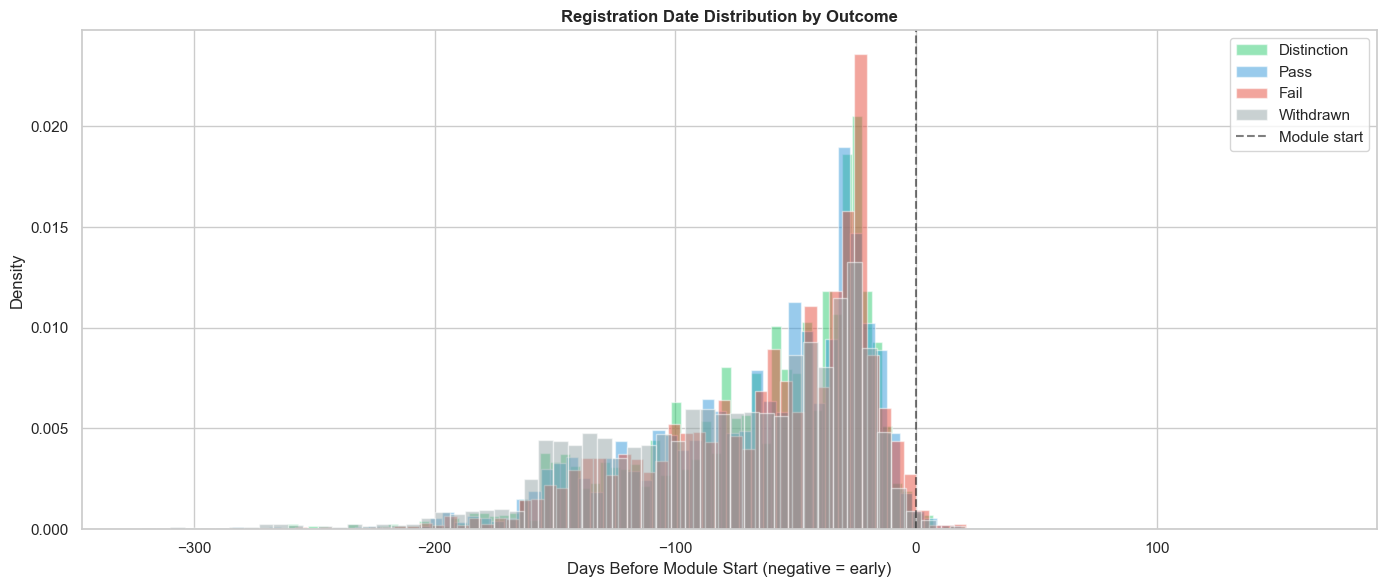

Mean registration date (days before start) by outcome:
  Distinction: -66 days
  Pass: -67 days
  Fail: -63 days
  Withdrawn: -78 days

Students who register earlier tend to perform better.


In [13]:
reg_outcome = student_reg.merge(
    student_info[['code_module', 'code_presentation', 'id_student', 'final_result']],
    on=['code_module', 'code_presentation', 'id_student'], how='inner'
)

fig, ax = plt.subplots(figsize=(14, 6))
for result, color in zip(order, colors):
    subset = reg_outcome[reg_outcome['final_result'] == result]['date_registration'].dropna()
    ax.hist(subset, bins=80, alpha=0.5, label=result, color=color, density=True)

ax.set_title('Registration Date Distribution by Outcome', fontweight='bold')
ax.set_xlabel('Days Before Module Start (negative = early)')
ax.set_ylabel('Density')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Module start')
ax.legend()
plt.tight_layout()
plt.savefig('registration_timing.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean registration date by outcome
mean_reg = reg_outcome.groupby('final_result')['date_registration'].mean().reindex(order)
print("Mean registration date (days before start) by outcome:")
for r, v in mean_reg.items():
    print(f"  {r}: {v:.0f} days")
print("\nStudents who register earlier tend to perform better.")

## **Step 14 — Studied Credits and Previous Attempts**

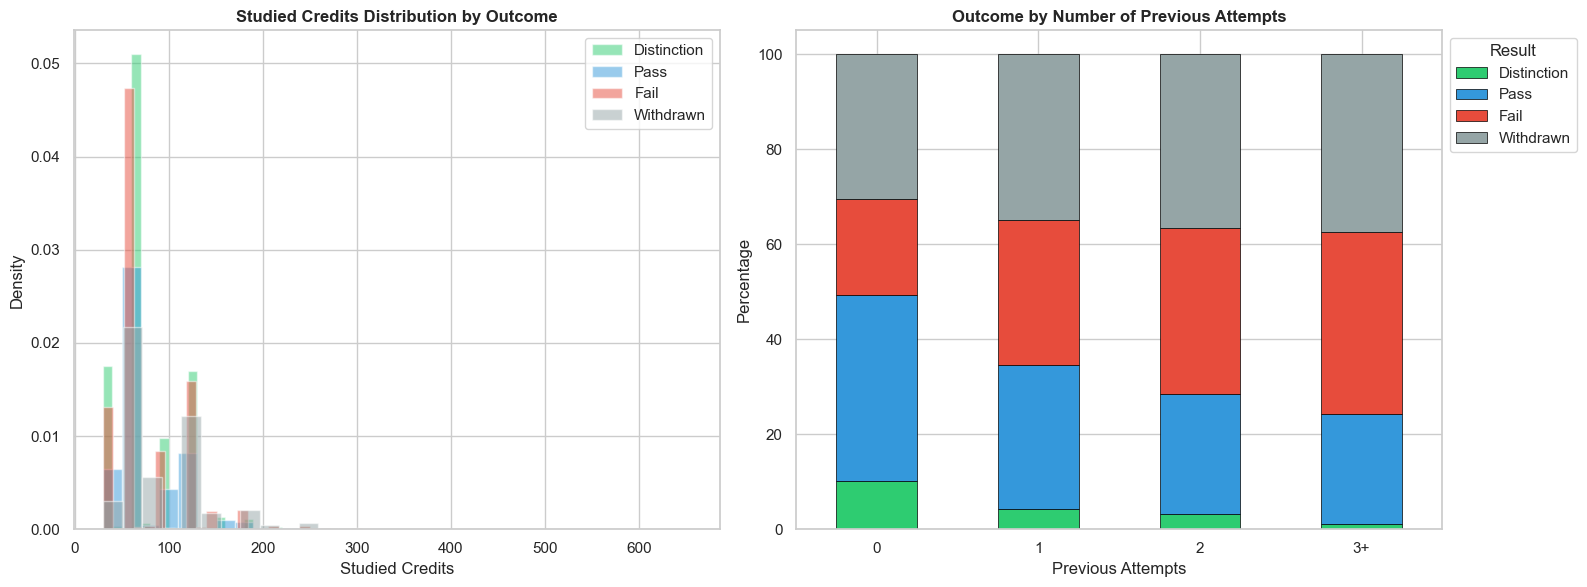

Key findings:
  - Students taking more credits tend to have diverse outcomes.
  - 87.2% of students are first-time takers.
  - Repeating students may have different outcome patterns.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Studied credits by outcome
for result, color in zip(order, colors):
    subset = student_info[student_info['final_result'] == result]['studied_credits']
    axes[0].hist(subset, bins=30, alpha=0.5, label=result, color=color, density=True)
axes[0].set_title('Studied Credits Distribution by Outcome', fontweight='bold')
axes[0].set_xlabel('Studied Credits')
axes[0].set_ylabel('Density')
axes[0].legend()

# Previous attempts
prev_outcome = pd.crosstab(
    student_info['num_of_prev_attempts'].clip(upper=3).replace({3: '3+'}),
    student_info['final_result'], normalize='index'
).reindex(columns=order) * 100
prev_outcome.plot(kind='bar', stacked=True, color=colors, ax=axes[1], edgecolor='black', linewidth=0.5)
axes[1].set_title('Outcome by Number of Previous Attempts', fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Previous Attempts')
axes[1].legend(title='Result', bbox_to_anchor=(1.0, 1.0))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('credits_attempts.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key findings:")
print("  - Students taking more credits tend to have diverse outcomes.")
print(f"  - {(student_info['num_of_prev_attempts']==0).mean()*100:.1f}% of students are first-time takers.")
print("  - Repeating students may have different outcome patterns.")

## **Step 15 — Feature Correlation Analysis**

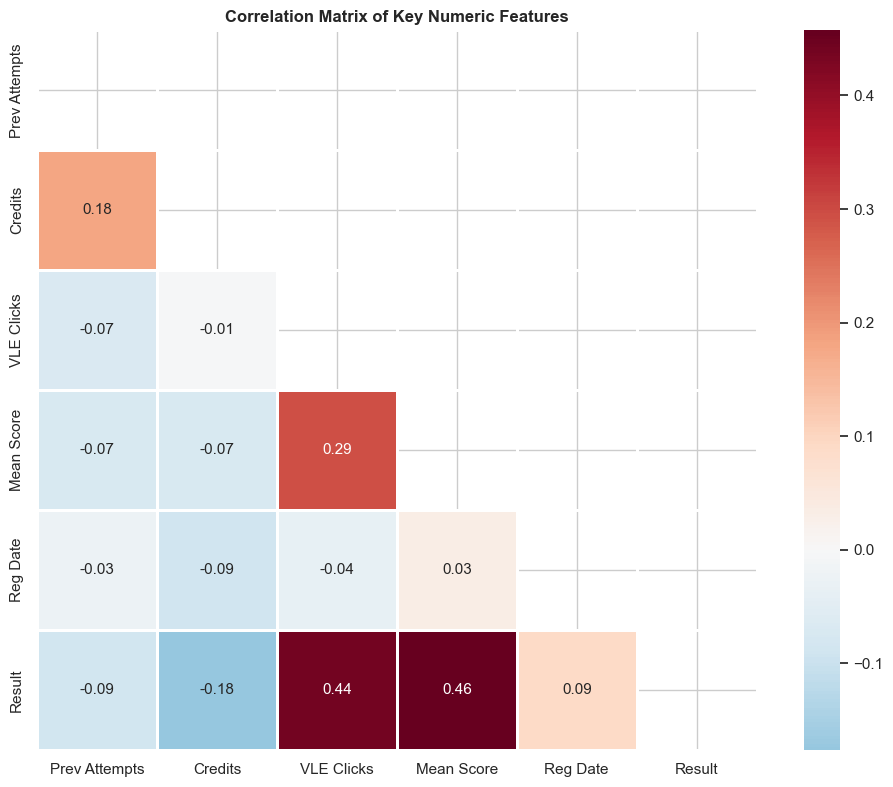

Key correlations with result_numeric (higher = better outcome):
  mean_score: +0.457
  total_clicks: +0.438
  date_registration: +0.092
  num_of_prev_attempts: -0.087
  studied_credits: -0.176


In [15]:
# Build a merged feature set for correlation
merged = student_info.merge(vle_student, on=['code_module', 'code_presentation', 'id_student'], how='left')

# Add mean assessment score
mean_score = assess_merged.groupby(['code_module', 'code_presentation', 'id_student'])['score'].mean().reset_index()
mean_score.rename(columns={'score': 'mean_score'}, inplace=True)
merged = merged.merge(mean_score, on=['code_module', 'code_presentation', 'id_student'], how='left')

# Add registration date
merged = merged.merge(
    student_reg[['code_module', 'code_presentation', 'id_student', 'date_registration']],
    on=['code_module', 'code_presentation', 'id_student'], how='left'
)

# Encode target numerically for correlation
result_map = {'Distinction': 3, 'Pass': 2, 'Fail': 1, 'Withdrawn': 0}
merged['result_numeric'] = merged['final_result'].map(result_map)

# Select numeric features
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_score',
            'date_registration', 'result_numeric']
corr = merged[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=ax,
            xticklabels=['Prev Attempts', 'Credits', 'VLE Clicks', 'Mean Score', 'Reg Date', 'Result'],
            yticklabels=['Prev Attempts', 'Credits', 'VLE Clicks', 'Mean Score', 'Reg Date', 'Result'])
ax.set_title('Correlation Matrix of Key Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key correlations with result_numeric (higher = better outcome):")
result_corr = corr['result_numeric'].drop('result_numeric').sort_values(ascending=False)
for feat, val in result_corr.items():
    print(f"  {feat}: {val:+.3f}")

## **Step 16 — Temporal Stability Check (RQ3)**

For RQ3, we need to verify that outcome distributions and feature relationships are comparable across presentations (semesters), so that training on earlier data and testing on later data is valid.

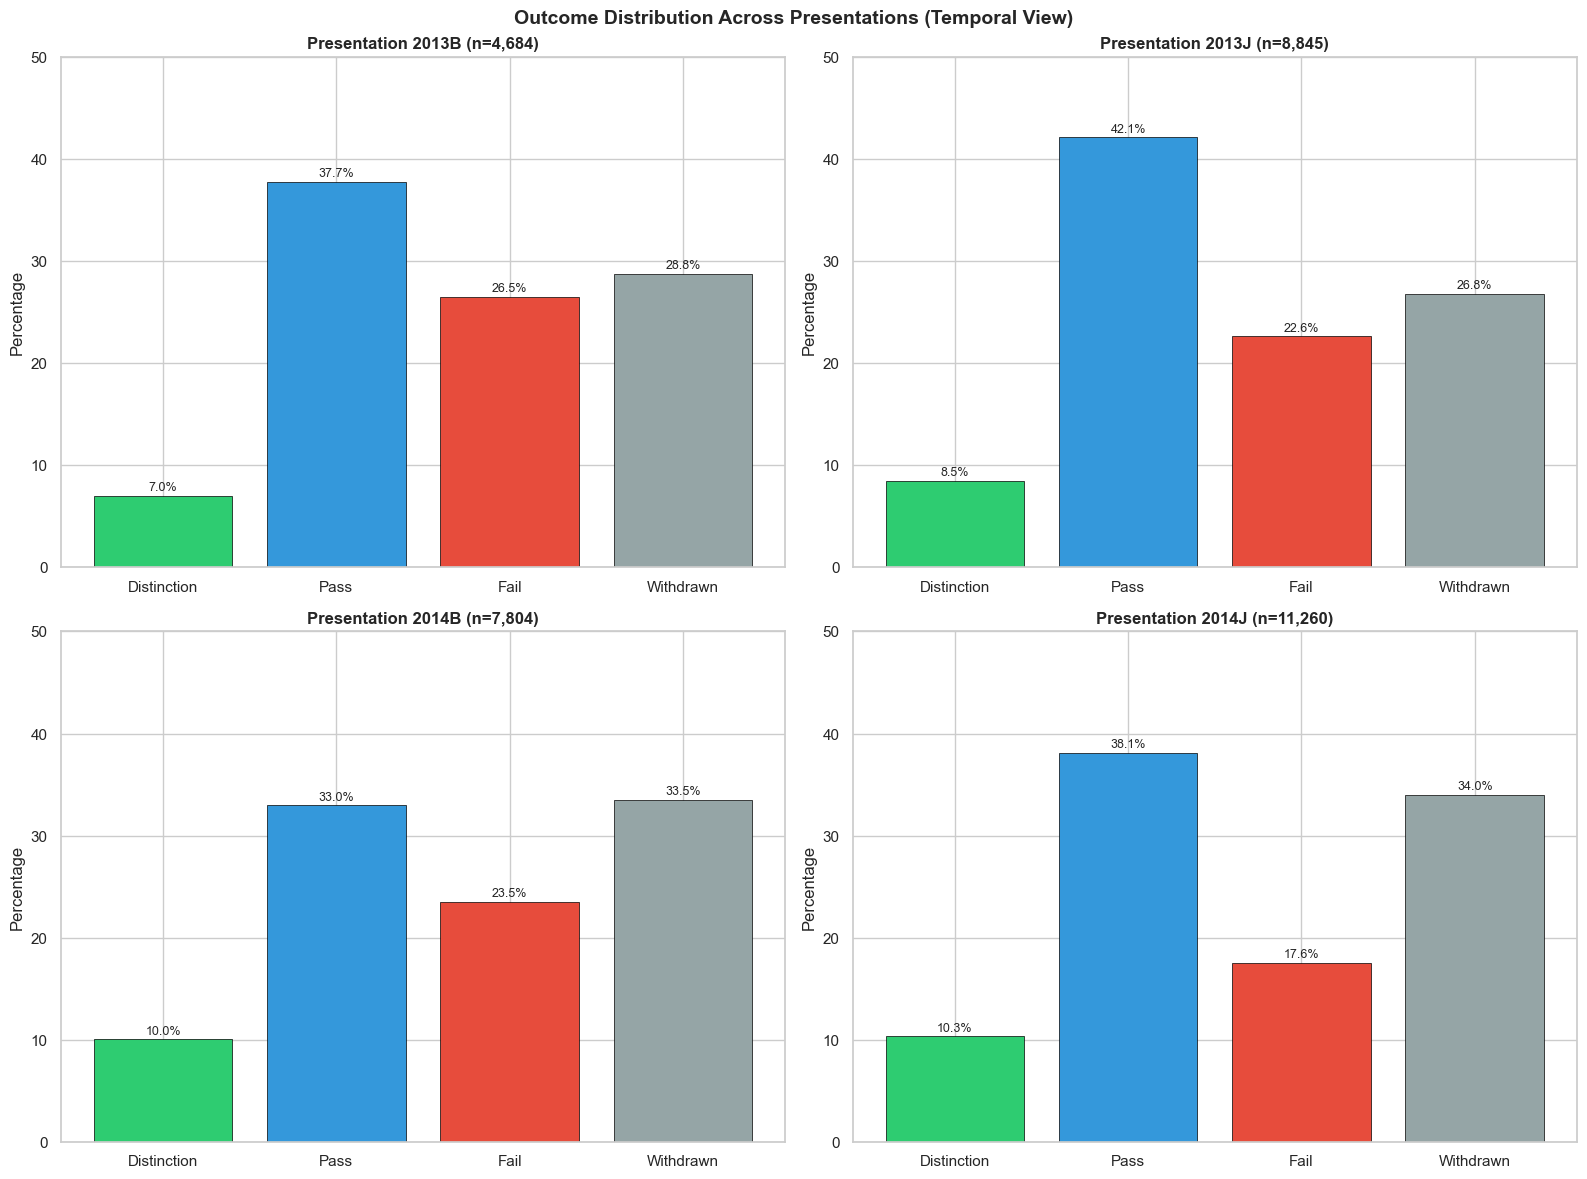

Outcome percentages per presentation:
final_result       Distinction  Pass  Fail  Withdrawn
code_presentation                                    
2013B                      7.0  37.7  26.5       28.8
2013J                      8.5  42.1  22.6       26.8
2014B                     10.0  33.0  23.5       33.5
2014J                     10.3  38.1  17.6       34.0

Std deviation across presentations:
final_result
Distinction    1.55
Pass           3.74
Fail           3.71
Withdrawn      3.54

Low std (<3%) indicates stable distributions — good for RQ3 temporal splits.


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

presentations = ['2013B', '2013J', '2014B', '2014J']
for i, pres in enumerate(presentations):
    ax = axes[i // 2][i % 2]
    subset = student_info[student_info['code_presentation'] == pres]
    outcome_pct = subset['final_result'].value_counts(normalize=True).reindex(order) * 100
    ax.bar(order, outcome_pct.values, color=colors, edgecolor='black', linewidth=0.5)
    for j, v in enumerate(outcome_pct.values):
        ax.text(j, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
    ax.set_title(f'Presentation {pres} (n={len(subset):,})', fontweight='bold')
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 50)

plt.suptitle('Outcome Distribution Across Presentations (Temporal View)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('temporal_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute stability metrics
print("Outcome percentages per presentation:")
stability = pd.crosstab(student_info['code_presentation'], student_info['final_result'], normalize='index').reindex(columns=order) * 100
print(stability.round(1).to_string())
print(f"\nStd deviation across presentations:")
print(stability.std().round(2).to_string())
print("\nLow std (<3%) indicates stable distributions — good for RQ3 temporal splits.")

---
# **PART B — Feature Engineering and Modelling**
---

> **Note:** All OULAD tables (`courses`, `assessments`, `studentInfo`, `studentRegistration`, `studentAssessment`, `vle`) were loaded once in **Part A, Step 2** and are reused here — no need to reload them.

## **Step 1 — Feature Engineering**

We engineer features from four sources:
1. **Demographic features** from `studentInfo`
2. **Academic features** from `studentAssessment` (aggregated per student)
3. **Behavioural features** from `studentVle` (VLE engagement aggregated per student)
4. **Registration features** from `studentRegistration`

All features are aggregated to the student-module-presentation level to match the target variable.

In [17]:
# --- 3a. Academic features from studentAssessment ---
print("Engineering academic features...")

# Merge assessment metadata
assess_full = student_assess.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type', 'weight']],
    on='id_assessment', how='left'
)

# Aggregate per student-module-presentation
academic_feats = assess_full.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    mean_score        = ('score', 'mean'),
    std_score         = ('score', 'std'),
    min_score         = ('score', 'min'),
    max_score         = ('score', 'max'),
    num_submissions   = ('score', 'count'),
    num_banked        = ('is_banked', 'sum'),
    mean_submit_day   = ('date_submitted', 'mean'),
    weighted_score    = ('score', lambda x: np.average(x.dropna(),
                         weights=assess_full.loc[x.dropna().index, 'weight'].fillna(1).replace(0, 1))
                         if len(x.dropna()) > 0 and assess_full.loc[x.dropna().index, 'weight'].fillna(1).sum() > 0 else np.nan)
).reset_index()

# TMA vs CMA vs Exam score breakdown
for atype in ['TMA', 'CMA', 'Exam']:
    subset = assess_full[assess_full['assessment_type'] == atype]
    agg = subset.groupby(['code_module', 'code_presentation', 'id_student'])['score'].mean().reset_index()
    agg.rename(columns={'score': f'mean_score_{atype}'}, inplace=True)
    academic_feats = academic_feats.merge(agg, on=['code_module', 'code_presentation', 'id_student'], how='left')

academic_feats['std_score'] = academic_feats['std_score'].fillna(0)

print(f"Academic features: {academic_feats.shape}")
print(f"Columns: {academic_feats.columns.tolist()}")

Engineering academic features...


Academic features: (25843, 14)
Columns: ['code_module', 'code_presentation', 'id_student', 'mean_score', 'std_score', 'min_score', 'max_score', 'num_submissions', 'num_banked', 'mean_submit_day', 'weighted_score', 'mean_score_TMA', 'mean_score_CMA', 'mean_score_Exam']


In [18]:
# --- 3b. Behavioural features from studentVle (chunked reading) ---
print("Engineering VLE behavioural features (chunked reading of 10.6M rows)...")

# Pass 1: total clicks + distinct days + distinct activities
vle_agg_list = []
chunk_iter = pd.read_csv(DATA_DIR + 'studentVle.csv', chunksize=500000)

for i, chunk in enumerate(chunk_iter):
    # Merge activity type
    chunk = chunk.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')
    
    agg = chunk.groupby(['code_module', 'code_presentation', 'id_student']).agg(
        total_clicks   = ('sum_click', 'sum'),
        distinct_days  = ('date', 'nunique'),
        distinct_sites = ('id_site', 'nunique')
    ).reset_index()
    vle_agg_list.append(agg)
    if (i + 1) % 5 == 0:
        print(f"  Processed {(i+1)*500000:,} rows...")

vle_concat = pd.concat(vle_agg_list, ignore_index=True)
vle_feats = vle_concat.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    total_clicks   = ('total_clicks', 'sum'),
    distinct_days  = ('distinct_days', 'max'),
    distinct_sites = ('distinct_sites', 'max')
).reset_index()

print(f"\nVLE features: {vle_feats.shape}")

# Pass 2: clicks by top activity types
print("\nAggregating clicks by activity type...")
activity_agg_list = []
chunk_iter = pd.read_csv(DATA_DIR + 'studentVle.csv', chunksize=500000)

for chunk in chunk_iter:
    chunk = chunk.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')
    agg = chunk.groupby(['code_module', 'code_presentation', 'id_student', 'activity_type'])['sum_click'].sum().reset_index()
    activity_agg_list.append(agg)

activity_concat = pd.concat(activity_agg_list, ignore_index=True)
activity_final = activity_concat.groupby(['code_module', 'code_presentation', 'id_student', 'activity_type'])['sum_click'].sum().reset_index()

# Pivot top activity types
top_activities = ['oucontent', 'forumng', 'resource', 'subpage', 'homepage', 'quiz', 'url', 'glossary']
activity_pivot = activity_final[activity_final['activity_type'].isin(top_activities)].pivot_table(
    index=['code_module', 'code_presentation', 'id_student'],
    columns='activity_type', values='sum_click', fill_value=0
).reset_index()
activity_pivot.columns = ['code_module', 'code_presentation', 'id_student'] + [f'clicks_{c}' for c in activity_pivot.columns[3:]]

vle_feats = vle_feats.merge(activity_pivot, on=['code_module', 'code_presentation', 'id_student'], how='left')
vle_feats = vle_feats.fillna(0)

print(f"VLE features with activity breakdown: {vle_feats.shape}")

Engineering VLE behavioural features (chunked reading of 10.6M rows)...


  Processed 2,500,000 rows...


  Processed 5,000,000 rows...


  Processed 7,500,000 rows...


  Processed 10,000,000 rows...

VLE features: (29228, 6)

Aggregating clicks by activity type...


VLE features with activity breakdown: (29228, 14)


In [19]:
# --- 3c. Registration features ---
print("Engineering registration features...")

reg_feats = student_reg[['code_module', 'code_presentation', 'id_student', 'date_registration']].copy()
reg_feats['is_late_registration'] = (reg_feats['date_registration'] > 0).astype(int)

# Add unregistration info
unreg = student_reg[['code_module', 'code_presentation', 'id_student', 'date_unregistration']].copy()
unreg['did_unregister'] = unreg['date_unregistration'].notna().astype(int)
reg_feats = reg_feats.merge(unreg[['code_module', 'code_presentation', 'id_student', 'did_unregister']],
                             on=['code_module', 'code_presentation', 'id_student'], how='left')

print(f"Registration features: {reg_feats.shape}")
print(f"Late registrations: {reg_feats['is_late_registration'].sum()} ({reg_feats['is_late_registration'].mean()*100:.1f}%)")

Engineering registration features...
Registration features: (32593, 6)
Late registrations: 234 (0.7%)


## **Step 2 — Merge All Features into Modelling Dataset**

In [20]:
# Start with studentInfo (contains target)
df = student_info.copy()

# Merge academic features
df = df.merge(academic_feats, on=['code_module', 'code_presentation', 'id_student'], how='left')

# Merge VLE features
df = df.merge(vle_feats, on=['code_module', 'code_presentation', 'id_student'], how='left')

# Merge registration features
df = df.merge(reg_feats, on=['code_module', 'code_presentation', 'id_student'], how='left')

# Merge module length from courses
df = df.merge(courses, on=['code_module', 'code_presentation'], how='left')

print(f"Merged dataset: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print(f"\nTarget distribution:")
print(df['final_result'].value_counts())

Merged dataset: (32593, 38)

Columns (38):
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'mean_score', 'std_score', 'min_score', 'max_score', 'num_submissions', 'num_banked', 'mean_submit_day', 'weighted_score', 'mean_score_TMA', 'mean_score_CMA', 'mean_score_Exam', 'total_clicks', 'distinct_days', 'distinct_sites', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url', 'date_registration', 'is_late_registration', 'did_unregister', 'module_presentation_length']

Missing values (top 10):
mean_score_Exam    27634
mean_score_CMA     17493
weighted_score      9109
mean_score_TMA      7805
mean_score          6773
max_score           6773
min_score           6773
mean_submit_day     6750
num_banked          6750
num_submissions     6750
dtype: int64

Target distrib

## **Step 3 — Handle Missing Values and Encode Categoricals**

In [21]:
# Fill missing VLE features with 0 (students who never accessed VLE)
vle_cols = [c for c in df.columns if c.startswith('clicks_') or c.startswith('total_') or c.startswith('distinct_')]
df[vle_cols] = df[vle_cols].fillna(0)

# Fill missing academic features
academic_fill_cols = ['mean_score', 'std_score', 'min_score', 'max_score',
                      'num_submissions', 'num_banked', 'mean_submit_day', 'weighted_score',
                      'mean_score_TMA', 'mean_score_CMA', 'mean_score_Exam']
df[academic_fill_cols] = df[academic_fill_cols].fillna(0)

# Fill missing registration
df['date_registration'] = df['date_registration'].fillna(0)
df['is_late_registration'] = df['is_late_registration'].fillna(0)
df['did_unregister'] = df['did_unregister'].fillna(0)

# Fix imd_band
df['imd_band'] = df['imd_band'].replace({'10-20': '10-20%'})
df['imd_band'] = df['imd_band'].fillna('Unknown')

# Encode categorical variables
cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
            'disability', 'code_module']

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Encode target: 0=Withdrawn, 1=Fail, 2=Pass, 3=Distinction
TARGET = 'final_result'
RESULT_MAP = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
RESULT_NAMES = {0: 'Withdrawn', 1: 'Fail', 2: 'Pass', 3: 'Distinction'}
LABEL_NAMES = ['Withdrawn', 'Fail', 'Pass', 'Distinction']

df['target'] = df[TARGET].map(RESULT_MAP)

print("Target encoding:", RESULT_MAP)
print("\nTarget distribution after encoding:")
print(df['target'].value_counts().sort_index())
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print(f"\nDataset shape: {df.shape}")

Target encoding: {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}

Target distribution after encoding:
target
0    10156
1     7052
2    12361
3     3024
Name: count, dtype: int64

Missing values remaining: 0

Dataset shape: (32593, 46)


## **Step 4 — Feature Selection**

> **Leakage control (revision after marker feedback):** `did_unregister` is *excluded* from the model. It is derived from `date_unregistration` and therefore encodes the Withdrawn outcome directly, which is only known once a student has left. Removing it drops macro-F1 from ~0.86 to ~0.72, which is the honest performance of an early-warning system restricted to information available *before* the outcome is decided. All other features (assessment, VLE, demographic, registration timing) are retained.

In [22]:
# Select features for modelling
FEATURES = [
    # Demographic (encoded)
    'gender_enc', 'age_band_enc', 'highest_education_enc', 'imd_band_enc',
    'disability_enc', 'code_module_enc',
    # Numeric demographic
    'num_of_prev_attempts', 'studied_credits',
    # Academic
    'mean_score', 'std_score', 'min_score', 'max_score',
    'num_submissions', 'num_banked', 'mean_submit_day', 'weighted_score',
    'mean_score_TMA', 'mean_score_CMA', 'mean_score_Exam',
    # Behavioural (VLE)
    'total_clicks', 'distinct_days', 'distinct_sites',
    'clicks_oucontent', 'clicks_forumng', 'clicks_resource',
    'clicks_subpage', 'clicks_homepage', 'clicks_quiz', 'clicks_url', 'clicks_glossary',
    # Registration
    'date_registration', 'is_late_registration',  # did_unregister REMOVED: outcome-leaking (derived from date_unregistration)
    # Course
    'module_presentation_length'
]

# Verify all features exist
missing_feats = [f for f in FEATURES if f not in df.columns]
if missing_feats:
    print(f"WARNING: Missing features: {missing_feats}")
    FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].copy()
y = df['target'].copy()

# Drop any remaining NaN rows
mask = X.isnull().any(axis=1) | y.isnull()
print(f"Dropping {mask.sum()} rows with remaining NaN values")
X = X[~mask]
y = y[~mask]

print(f"\nFinal feature matrix: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

Dropping 0 rows with remaining NaN values

Final feature matrix: (32593, 33)
Target shape: (32593,)

Features (33):
   1. gender_enc
   2. age_band_enc
   3. highest_education_enc
   4. imd_band_enc
   5. disability_enc
   6. code_module_enc
   7. num_of_prev_attempts
   8. studied_credits
   9. mean_score
  10. std_score
  11. min_score
  12. max_score
  13. num_submissions
  14. num_banked
  15. mean_submit_day
  16. weighted_score
  17. mean_score_TMA
  18. mean_score_CMA
  19. mean_score_Exam
  20. total_clicks
  21. distinct_days
  22. distinct_sites
  23. clicks_oucontent
  24. clicks_forumng
  25. clicks_resource
  26. clicks_subpage
  27. clicks_homepage
  28. clicks_quiz
  29. clicks_url
  30. clicks_glossary
  31. date_registration
  32. is_late_registration
  33. module_presentation_length


## **Step 5 — Stratified Train/Test Split (80/20)**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts().sort_index().rename(RESULT_NAMES))
print(f"\nTest target distribution:")
print(y_test.value_counts().sort_index().rename(RESULT_NAMES))
print(f"\nClass proportions preserved (stratified):")
for cls in sorted(y.unique()):
    train_pct = (y_train == cls).mean() * 100
    test_pct = (y_test == cls).mean() * 100
    print(f"  {RESULT_NAMES[cls]:12s}: train={train_pct:.1f}%  test={test_pct:.1f}%")

Training set: (26074, 33)
Test set:     (6519, 33)

Training target distribution:
target
Withdrawn      8125
Fail           5641
Pass           9889
Distinction    2419
Name: count, dtype: int64

Test target distribution:
target
Withdrawn      2031
Fail           1411
Pass           2472
Distinction     605
Name: count, dtype: int64

Class proportions preserved (stratified):
  Withdrawn   : train=31.2%  test=31.2%
  Fail        : train=21.6%  test=21.6%
  Pass        : train=37.9%  test=37.9%
  Distinction : train=9.3%  test=9.3%


## **Step 6 — Baseline Models (No Resampling)**

Train all three ensemble models without any resampling to establish baselines.

In [24]:
MODELS = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42, n_jobs=-1, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=12, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced',
        objective='multiclass', metric='multi_logloss',
        random_state=42, n_jobs=-1, verbose=-1
    )
}

baseline_results = {}

for name, model in MODELS.items():
    print(f"\nTraining {name} (baseline, no resampling)...")
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    baseline_results[name] = {
        'model': model, 'y_pred': y_pred,
        'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'time': elapsed
    }
    
    print(f"  Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f} | Time: {elapsed:.1f}s")

print("\n=== Baseline Comparison ===")
baseline_df = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'Macro-F1': r['macro_f1'],
           'Weighted-F1': r['weighted_f1'], 'Time(s)': r['time']}
    for name, r in baseline_results.items()
}).T
print(baseline_df.round(4).to_string())


Training Random Forest (baseline, no resampling)...
  Accuracy: 0.7503 | Macro-F1: 0.7117 | Weighted-F1: 0.7456 | Time: 2.4s

Training XGBoost (baseline, no resampling)...
  Accuracy: 0.7592 | Macro-F1: 0.7128 | Weighted-F1: 0.7509 | Time: 1.6s

Training LightGBM (baseline, no resampling)...
  Accuracy: 0.7478 | Macro-F1: 0.7172 | Weighted-F1: 0.7483 | Time: 1.0s

=== Baseline Comparison ===
               Accuracy  Macro-F1  Weighted-F1  Time(s)
Random Forest    0.7503    0.7117       0.7456   2.3648
XGBoost          0.7592    0.7128       0.7509   1.6193
LightGBM         0.7478    0.7172       0.7483   1.0241



=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

   Withdrawn     0.7677    0.8070    0.7868      2031
        Fail     0.6069    0.4848    0.5390      1411
        Pass     0.8361    0.8584    0.8471      2472
 Distinction     0.6203    0.7372    0.6737       605

    accuracy                         0.7503      6519
   macro avg     0.7077    0.7218    0.7117      6519
weighted avg     0.7451    0.7503    0.7456      6519


=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

   Withdrawn     0.7574    0.8099    0.7828      2031
        Fail     0.6047    0.4748    0.5320      1411
        Pass     0.8306    0.9142    0.8704      2472
 Distinction     0.7220    0.6182    0.6661       605

    accuracy                         0.7592      6519
   macro avg     0.7287    0.7043    0.7128      6519
weighted avg     0.7488    0.7592    0.7509      6519


=== LightGBM — Classification Report ===


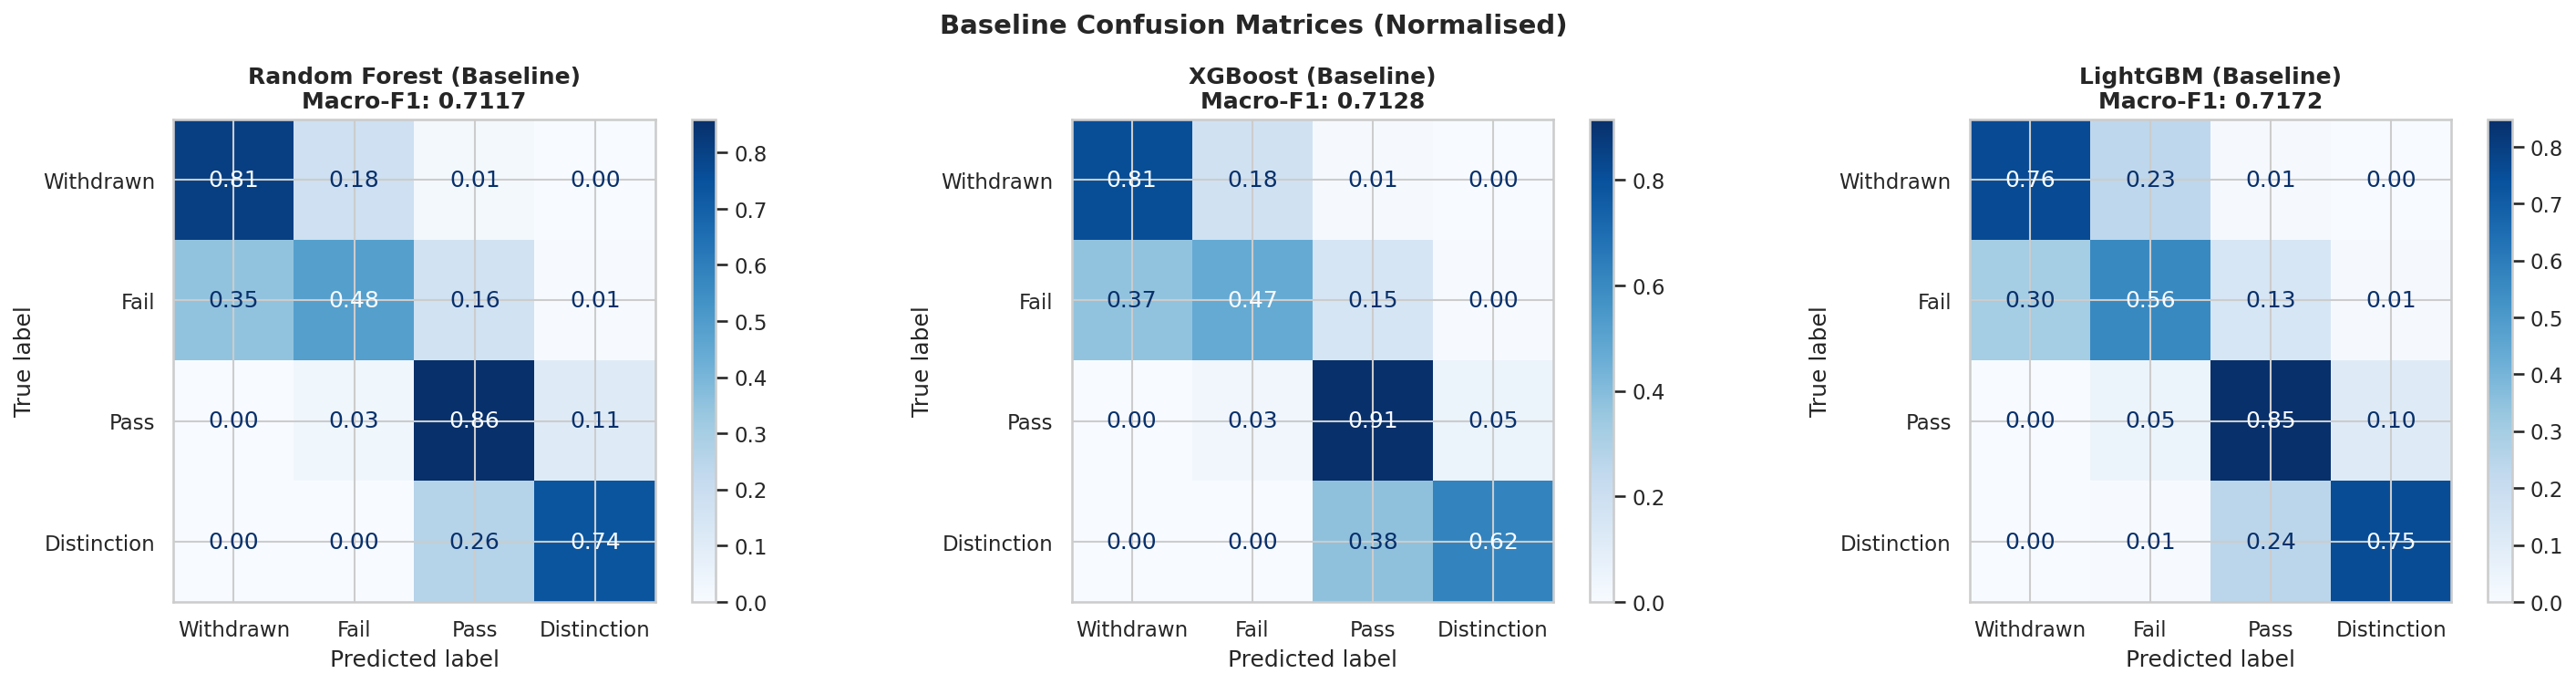

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, res) in enumerate(baseline_results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'], display_labels=LABEL_NAMES, ax=axes[i],
        cmap='Blues', normalize='true', values_format='.2f'
    )
    axes[i].set_title(f'{name} (Baseline)\nMacro-F1: {res["macro_f1"]:.4f}', fontweight='bold')

plt.suptitle('Baseline Confusion Matrices (Normalised)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('baseline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class reports
for name, res in baseline_results.items():
    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_test, res['y_pred'], target_names=LABEL_NAMES, digits=4))

## **Step 7 — Models with SMOTE Resampling (RQ1)**

Apply SMOTE to the training set to address class imbalance. Compare with baseline to measure impact on minority-class recall.

In [26]:
print("Applying SMOTE to training set...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nOriginal training set: {X_train.shape[0]} samples")
print(f"After SMOTE:           {X_train_smote.shape[0]} samples")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index().rename(RESULT_NAMES))

smote_results = {}

for name in MODELS:
    print(f"\nTraining {name} (with SMOTE)...")
    # Create fresh model instance
    if name == 'Random Forest':
        model = RandomForestClassifier(
            n_estimators=300, max_depth=15, min_samples_split=5,
            random_state=42, n_jobs=-1
        )
    elif name == 'XGBoost':
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=8, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=42, n_jobs=-1, verbosity=0
        )
    else:
        model = lgb.LGBMClassifier(
            n_estimators=300, max_depth=12, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
             objective='multiclass', metric='multi_logloss',
            random_state=42, n_jobs=-1, verbose=-1
        )
    
    start = time.time()
    model.fit(X_train_smote, y_train_smote)
    elapsed = time.time() - start
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    smote_results[name] = {
        'model': model, 'y_pred': y_pred,
        'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'time': elapsed
    }
    
    print(f"  Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}")

print("\n=== SMOTE Comparison ===")
smote_df = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'Macro-F1': r['macro_f1'],
           'Weighted-F1': r['weighted_f1']}
    for name, r in smote_results.items()
}).T
print(smote_df.round(4).to_string())

Applying SMOTE to training set...

Original training set: 26074 samples
After SMOTE:           39556 samples

Class distribution after SMOTE:
target
Withdrawn      9889
Fail           9889
Pass           9889
Distinction    9889
Name: count, dtype: int64

Training Random Forest (with SMOTE)...
  Accuracy: 0.7452 | Macro-F1: 0.7133 | Weighted-F1: 0.7439

Training XGBoost (with SMOTE)...
  Accuracy: 0.7549 | Macro-F1: 0.7169 | Weighted-F1: 0.7498

Training LightGBM (with SMOTE)...
  Accuracy: 0.7555 | Macro-F1: 0.7159 | Weighted-F1: 0.7504

=== SMOTE Comparison ===
               Accuracy  Macro-F1  Weighted-F1
Random Forest    0.7452    0.7133       0.7439
XGBoost          0.7549    0.7169       0.7498
LightGBM         0.7555    0.7159       0.7504


## **Step 7 — Models with ADASYN Resampling (RQ1)**

In [27]:
print("Applying ADASYN to training set...")
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print(f"After ADASYN: {X_train_adasyn.shape[0]} samples")
print(pd.Series(y_train_adasyn).value_counts().sort_index().rename(RESULT_NAMES))

adasyn_results = {}

for name in MODELS:
    print(f"\nTraining {name} (with ADASYN)...")
    if name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5, random_state=42, n_jobs=-1)
    elif name == 'XGBoost':
        model = xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0)
    else:
        model = lgb.LGBMClassifier(n_estimators=300, max_depth=12, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, objective='multiclass', metric='multi_logloss', random_state=42, n_jobs=-1, verbose=-1)
    
    start = time.time()
    model.fit(X_train_adasyn, y_train_adasyn)
    elapsed = time.time() - start
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    adasyn_results[name] = {
        'model': model, 'y_pred': y_pred,
        'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1
    }
    print(f"  Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}")

Applying ADASYN to training set...
After ADASYN: 38585 samples
target
Withdrawn      9300
Fail           9550
Pass           9889
Distinction    9846
Name: count, dtype: int64

Training Random Forest (with ADASYN)...
  Accuracy: 0.7464 | Macro-F1: 0.7144 | Weighted-F1: 0.7453

Training XGBoost (with ADASYN)...
  Accuracy: 0.7532 | Macro-F1: 0.7144 | Weighted-F1: 0.7475

Training LightGBM (with ADASYN)...
  Accuracy: 0.7593 | Macro-F1: 0.7216 | Weighted-F1: 0.7546


## **Step 8 — RQ1 Full Comparison: Baseline vs SMOTE vs ADASYN**

=== Full RQ1 Comparison ===
Strategy       ADASYN  Baseline   SMOTE
Model                                  
LightGBM       0.7216    0.7172  0.7159
Random Forest  0.7144    0.7117  0.7133
XGBoost        0.7144    0.7128  0.7169

Saved: rq1_model_comparison.csv

Best model: LightGBM with ADASYN
  Macro-F1: 0.7216 | Accuracy: 0.7593


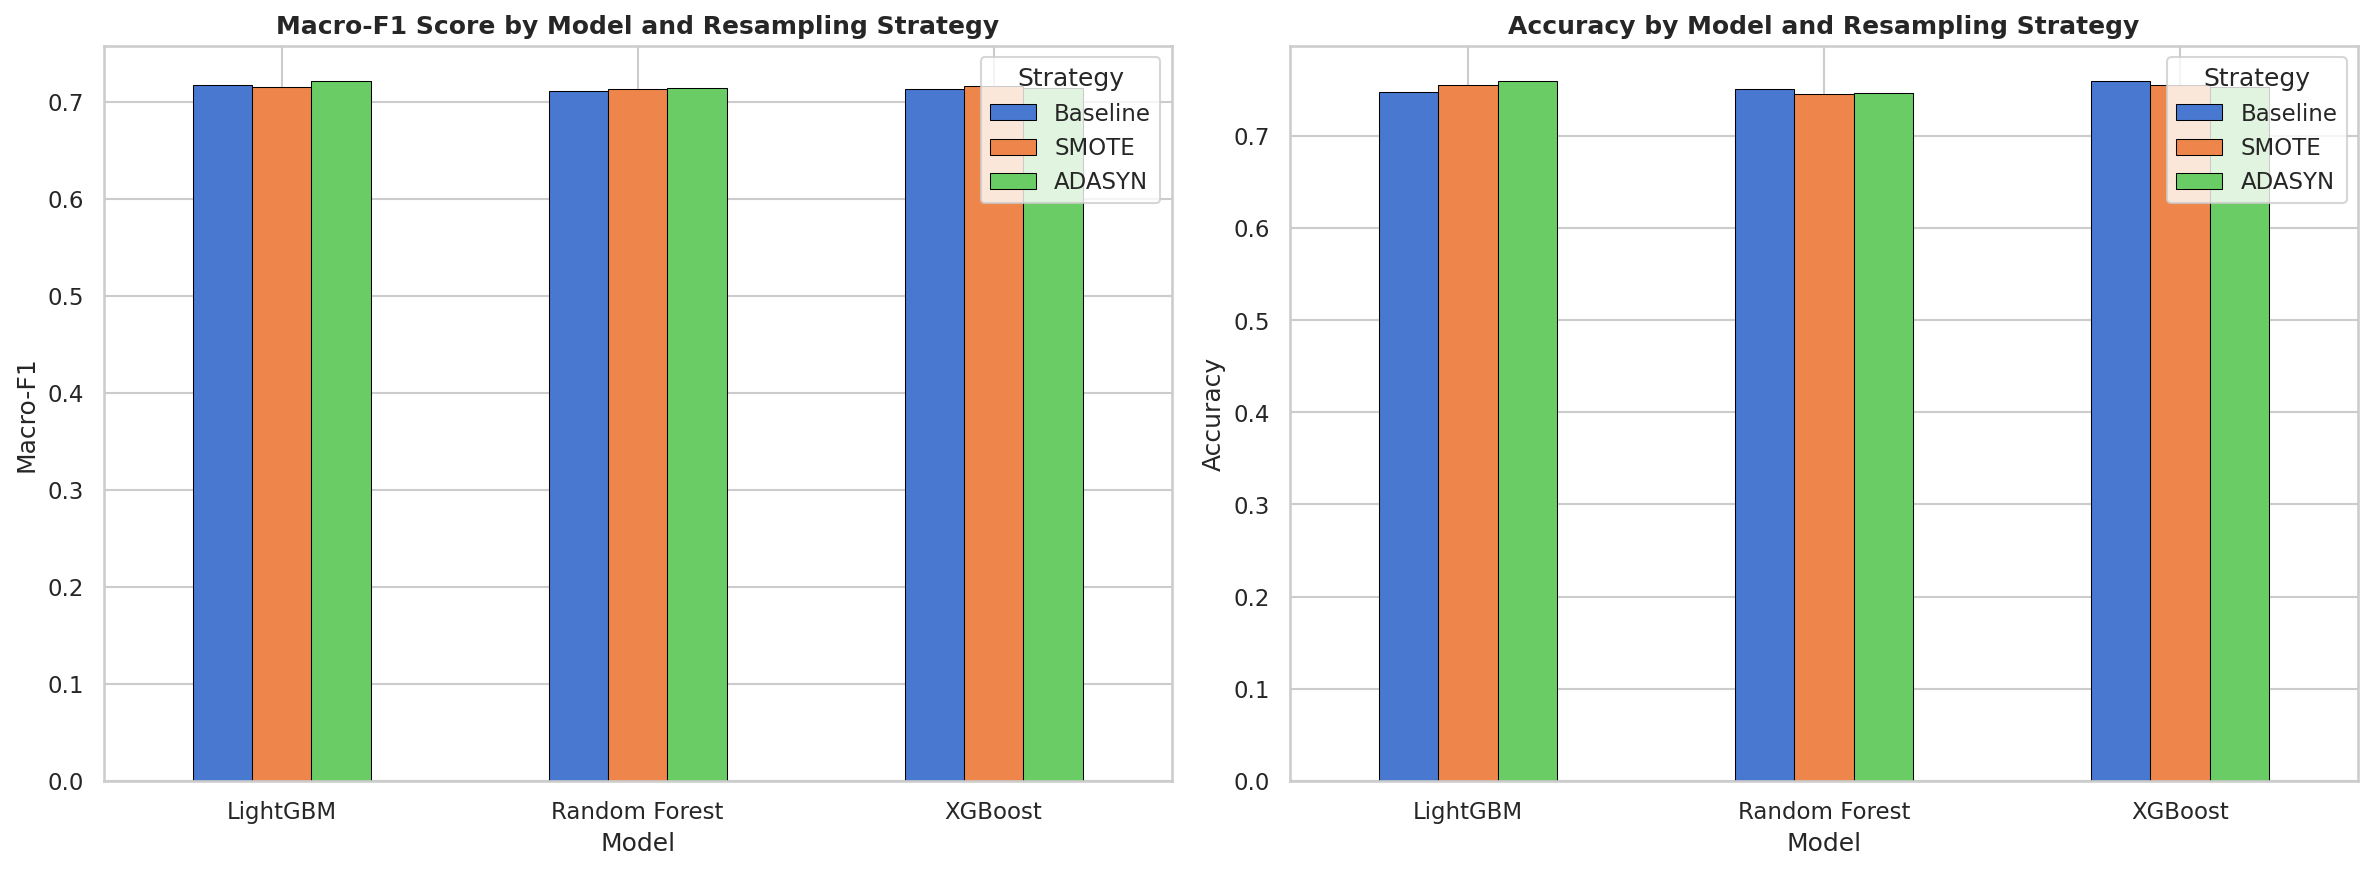

In [28]:
# Build comparison table
rows = []
for strategy, results in [('Baseline', baseline_results), ('SMOTE', smote_results), ('ADASYN', adasyn_results)]:
    for name, res in results.items():
        rows.append({
            'Model': name, 'Strategy': strategy,
            'Accuracy': res['accuracy'], 'Macro-F1': res['macro_f1'], 'Weighted-F1': res['weighted_f1']
        })

comparison_df = pd.DataFrame(rows)
print("=== Full RQ1 Comparison ===")
print(comparison_df.pivot_table(index='Model', columns='Strategy', values='Macro-F1').round(4).to_string())
print()

# Save comparison
comparison_df.to_csv('rq1_model_comparison.csv', index=False)
print("Saved: rq1_model_comparison.csv")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_macro = comparison_df.pivot_table(index='Model', columns='Strategy', values='Macro-F1')
pivot_macro[['Baseline', 'SMOTE', 'ADASYN']].plot(kind='bar', ax=axes[0], edgecolor='black', linewidth=0.5)
axes[0].set_title('Macro-F1 Score by Model and Resampling Strategy', fontweight='bold')
axes[0].set_ylabel('Macro-F1')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Strategy')

pivot_acc = comparison_df.pivot_table(index='Model', columns='Strategy', values='Accuracy')
pivot_acc[['Baseline', 'SMOTE', 'ADASYN']].plot(kind='bar', ax=axes[1], edgecolor='black', linewidth=0.5)
axes[1].set_title('Accuracy by Model and Resampling Strategy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Strategy')

plt.tight_layout()
plt.savefig('rq1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Best model selection
best_row = comparison_df.loc[comparison_df['Macro-F1'].idxmax()]
print(f"\nBest model: {best_row['Model']} with {best_row['Strategy']}")
print(f"  Macro-F1: {best_row['Macro-F1']:.4f} | Accuracy: {best_row['Accuracy']:.4f}")

## **Step 9 — Hyperparameter Tuning (Best Model)**

Tune the best-performing model using GridSearchCV with StratifiedKFold.

In [29]:
# Hyperparameter tuning of the deployed model (XGBoost + SMOTE), leakage-safe.
# A validation set is held out from the TRAINING data BEFORE SMOTE is applied, so that
# no synthetic (interpolated) sample can leak into validation. Six candidate
# configurations are scored on the clean validation set; the winner is then retrained
# on the full SMOTE-resampled training set and evaluated once on the held-out test set.
best_model_name, best_strategy = 'XGBoost', 'SMOTE'
print(f"Tuning: {best_model_name} with {best_strategy} (leakage-safe held-out validation)")

X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
X_tr2_s, y_tr2_s = SMOTE(random_state=42).fit_resample(X_tr2, y_tr2)  # SMOTE on train fold only

candidates = [
    dict(n_estimators=300, max_depth=6,  learning_rate=0.1,  subsample=0.8, colsample_bytree=0.8),
    dict(n_estimators=300, max_depth=8,  learning_rate=0.1,  subsample=0.8, colsample_bytree=0.8),
    dict(n_estimators=500, max_depth=8,  learning_rate=0.05, subsample=0.8, colsample_bytree=0.8),
    dict(n_estimators=300, max_depth=10, learning_rate=0.1,  subsample=0.8, colsample_bytree=0.8),
    dict(n_estimators=500, max_depth=6,  learning_rate=0.05, subsample=0.8, colsample_bytree=0.8),
    dict(n_estimators=500, max_depth=8,  learning_rate=0.1,  subsample=0.7, colsample_bytree=0.8),
]
best = None
for i, p in enumerate(candidates, 1):
    m = xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss',
                          random_state=42, n_jobs=-1, verbosity=0, **p)
    m.fit(X_tr2_s, y_tr2_s)
    vf1 = f1_score(y_val, m.predict(X_val), average='macro')
    print(f"  candidate {i}: max_depth={p['max_depth']}, n_estimators={p['n_estimators']}, "
          f"learning_rate={p['learning_rate']}  ->  validation macro-F1 = {vf1:.4f}")
    if best is None or vf1 > best[0]:
        best = (vf1, p)
print(f"\nBest configuration (validation macro-F1 = {best[0]:.4f}): {best[1]}")

X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
best_model = xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss',
                               random_state=42, n_jobs=-1, verbosity=0, **best[1])
best_model.fit(X_train_smote, y_train_smote)
y_pred_tuned = best_model.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1  = f1_score(y_test, y_pred_tuned, average='macro')
print(f"\nTuned model on test set:  Accuracy = {tuned_acc:.4f} | Macro-F1 = {tuned_f1:.4f}")
print("\nClassification Report (tuned XGBoost + SMOTE):")
print(classification_report(y_test, y_pred_tuned, target_names=LABEL_NAMES, digits=4))

Tuning: XGBoost with SMOTE (leakage-safe held-out validation)
  candidate 1: max_depth=6, n_estimators=300, learning_rate=0.1  ->  validation macro-F1 = 0.7132
  candidate 2: max_depth=8, n_estimators=300, learning_rate=0.1  ->  validation macro-F1 = 0.7060
  candidate 3: max_depth=8, n_estimators=500, learning_rate=0.05  ->  validation macro-F1 = 0.7099
  candidate 4: max_depth=10, n_estimators=300, learning_rate=0.1  ->  validation macro-F1 = 0.7090
  candidate 5: max_depth=6, n_estimators=500, learning_rate=0.05  ->  validation macro-F1 = 0.7107
  candidate 6: max_depth=8, n_estimators=500, learning_rate=0.1  ->  validation macro-F1 = 0.7032

Best configuration (validation macro-F1 = 0.7132): {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}

Tuned model on test set:  Accuracy = 0.7575 | Macro-F1 = 0.7220

Classification Report (tuned XGBoost + SMOTE):
              precision    recall  f1-score   support

   Withdrawn     0.7670 

Saved tuned model: best_model_tuned.pkl
Model: XGBoost (SMOTE)


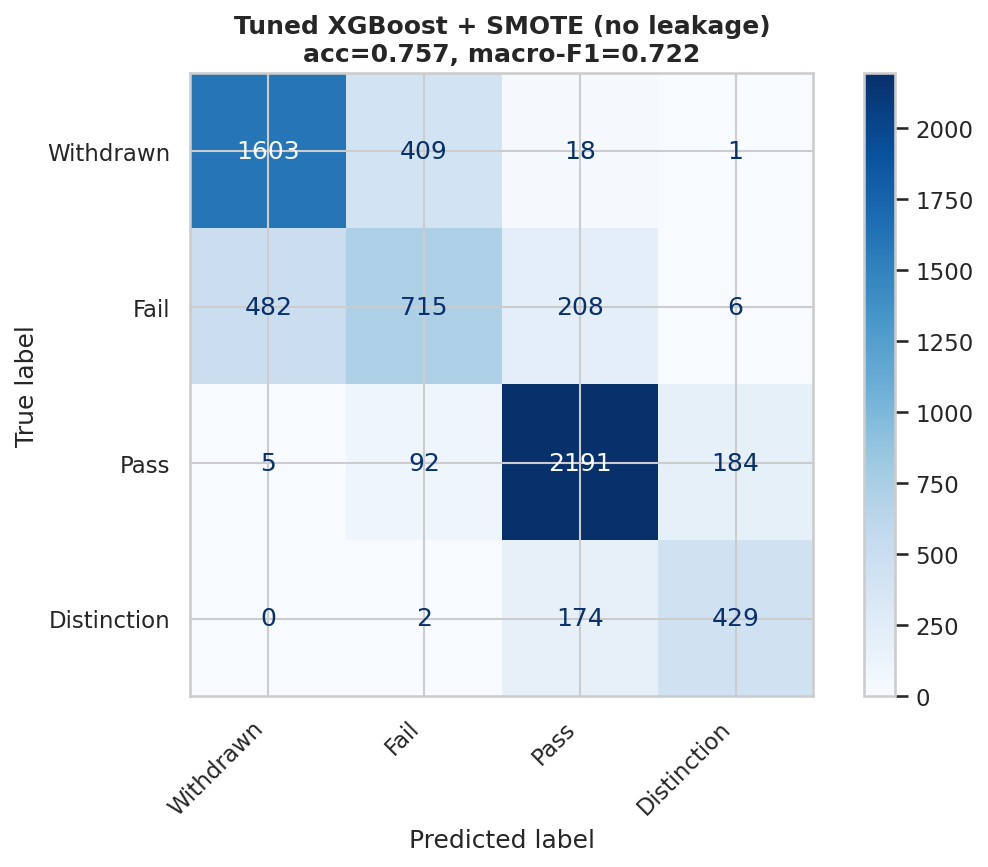

In [30]:
# Save the tuned model
with open('best_model_tuned.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"Saved tuned model: best_model_tuned.pkl")
print(f"Model: {best_model_name} ({best_strategy})")

# Tuned confusion matrix (counts)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tuned), display_labels=LABEL_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=True, values_format='d')
ax.set_title(f'Tuned {best_model_name} + {best_strategy} (no leakage)\n'
             f'acc={tuned_acc:.3f}, macro-F1={tuned_f1:.3f}', fontweight='bold')
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('tuned_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 10 — SHAP Explainability: Global Feature Importance (RQ2)**

Use SHAP TreeExplainer to identify which features contribute most to predictions across all classes.

Computing SHAP values (this may take a few minutes)...
SHAP values computed for 2000 test samples.
SHAP shape: 4 classes x (2000, 33)

Top 15 features by mean |SHAP|:
                   feature  mean_abs_shap
           mean_submit_day       1.154045
           num_submissions       0.767660
            weighted_score       0.394432
                mean_score       0.381718
           mean_score_Exam       0.368122
                 max_score       0.206373
             distinct_days       0.141354
          clicks_oucontent       0.128124
               clicks_quiz       0.120161
            mean_score_TMA       0.112242
            mean_score_CMA       0.106479
module_presentation_length       0.102943
           code_module_enc       0.099439
            clicks_subpage       0.094031
           studied_credits       0.094002


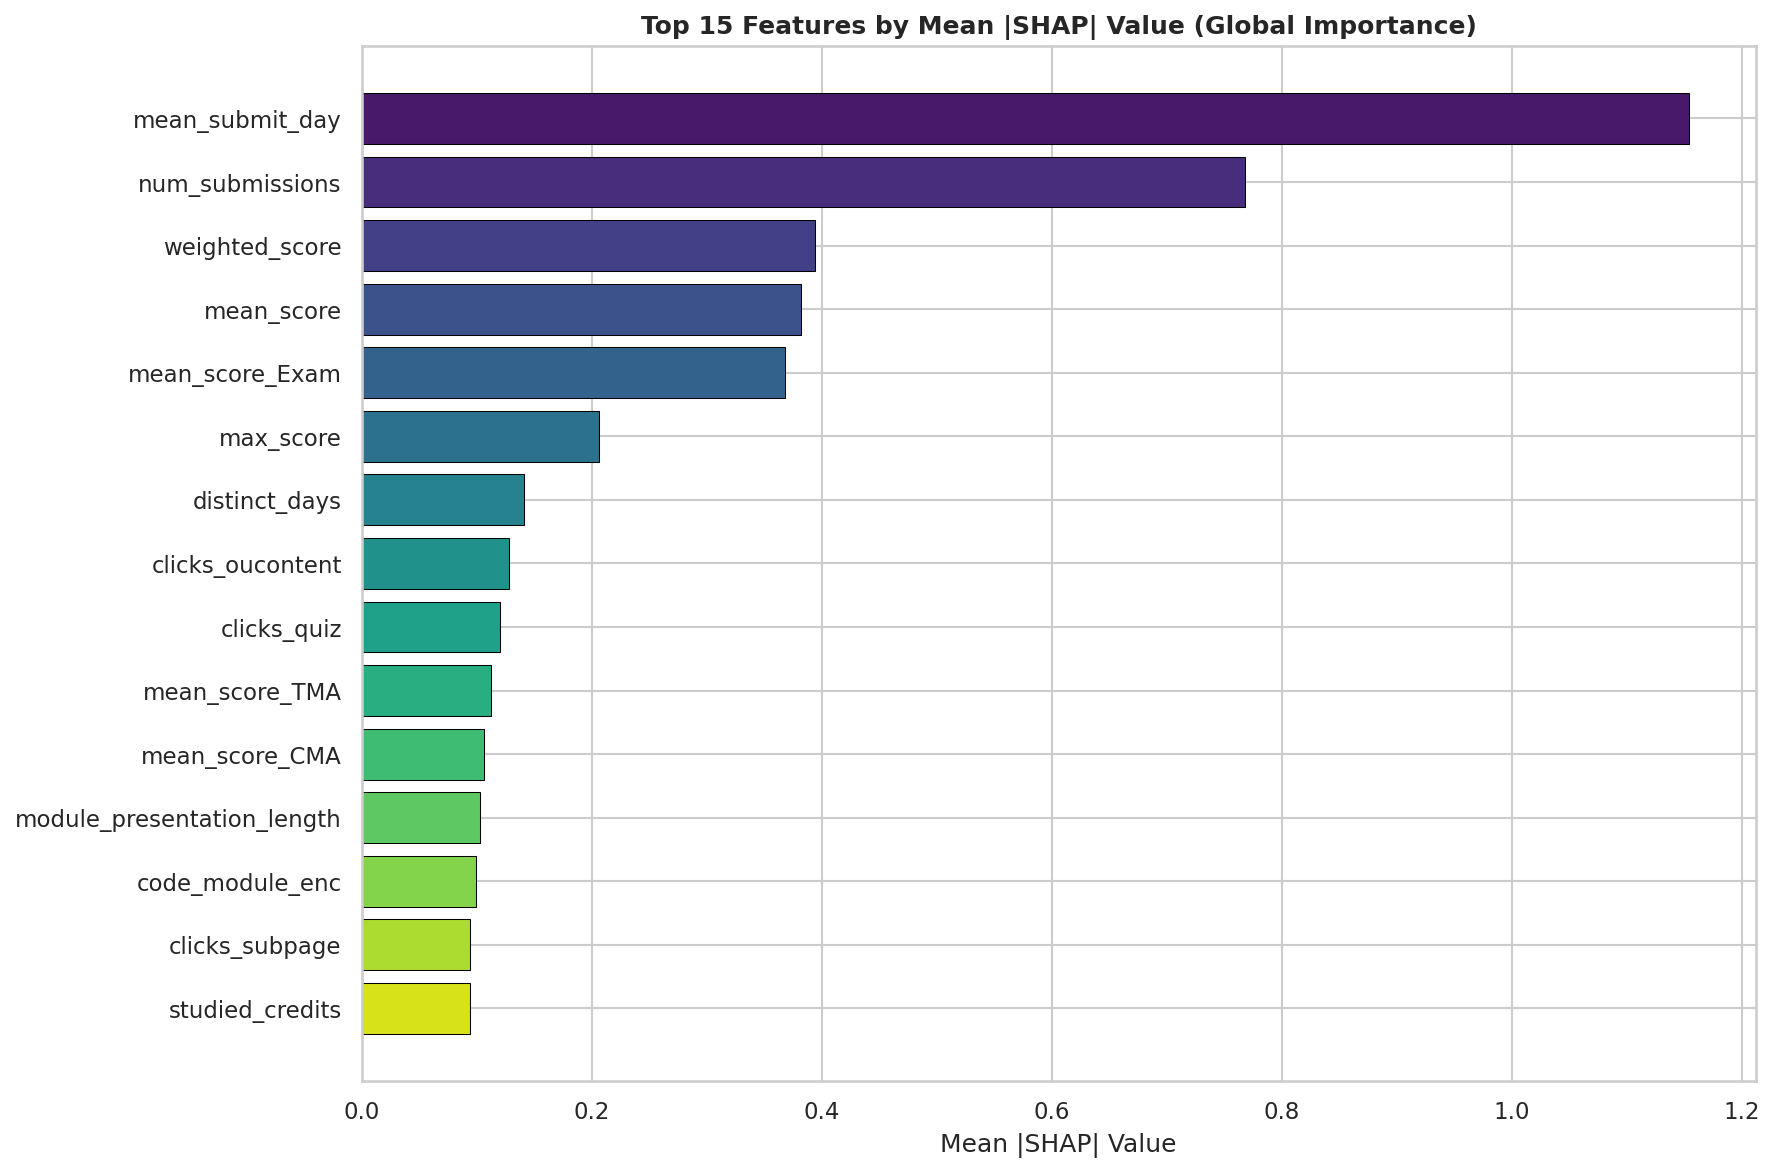

In [31]:
print("Computing SHAP values (this may take a few minutes)...")

# Use a sample for SHAP if dataset is large
SHAP_SAMPLE = min(2000, len(X_test))
X_shap = X_test.sample(n=SHAP_SAMPLE, random_state=42)
y_shap = y_test.loc[X_shap.index]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# Normalize: newer SHAP versions may return 3D ndarray (samples, features, classes)
# Convert to list of 2D arrays [class0_array, class1_array, ...] for consistency
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print(f"SHAP values computed for {SHAP_SAMPLE} test samples.")
if isinstance(shap_values, list):
    print(f"SHAP shape: {len(shap_values)} classes x {shap_values[0].shape}")
else:
    print(f"SHAP shape: {shap_values.shape}")

# Global feature importance (mean absolute SHAP across all classes)
if isinstance(shap_values, list):
    shap_abs_mean = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    shap_abs_mean = np.abs(shap_values).mean(axis=0)

feat_importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': shap_abs_mean
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 15 features by mean |SHAP|:")
print(feat_importance.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
top15 = feat_importance.head(15)
ax.barh(top15['feature'][::-1], top15['mean_abs_shap'][::-1],
        color=sns.color_palette('viridis', 15)[::-1], edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Features by Mean |SHAP| Value (Global Importance)', fontweight='bold')
ax.set_xlabel('Mean |SHAP| Value')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## **Step 11 — SHAP Summary Plot (Beeswarm)**

SHAP beeswarm plots generated for all classes.


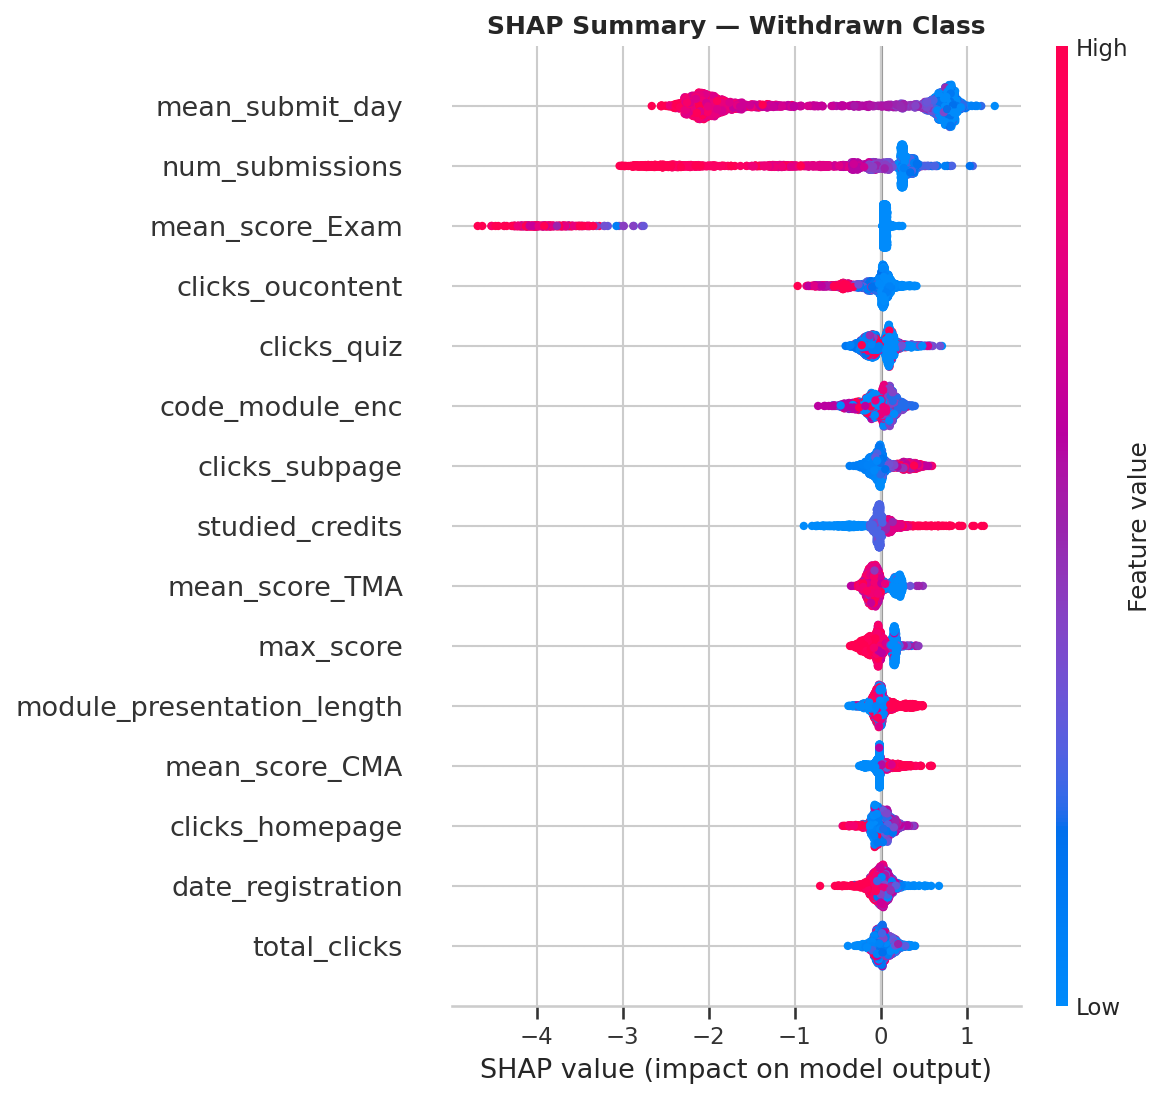

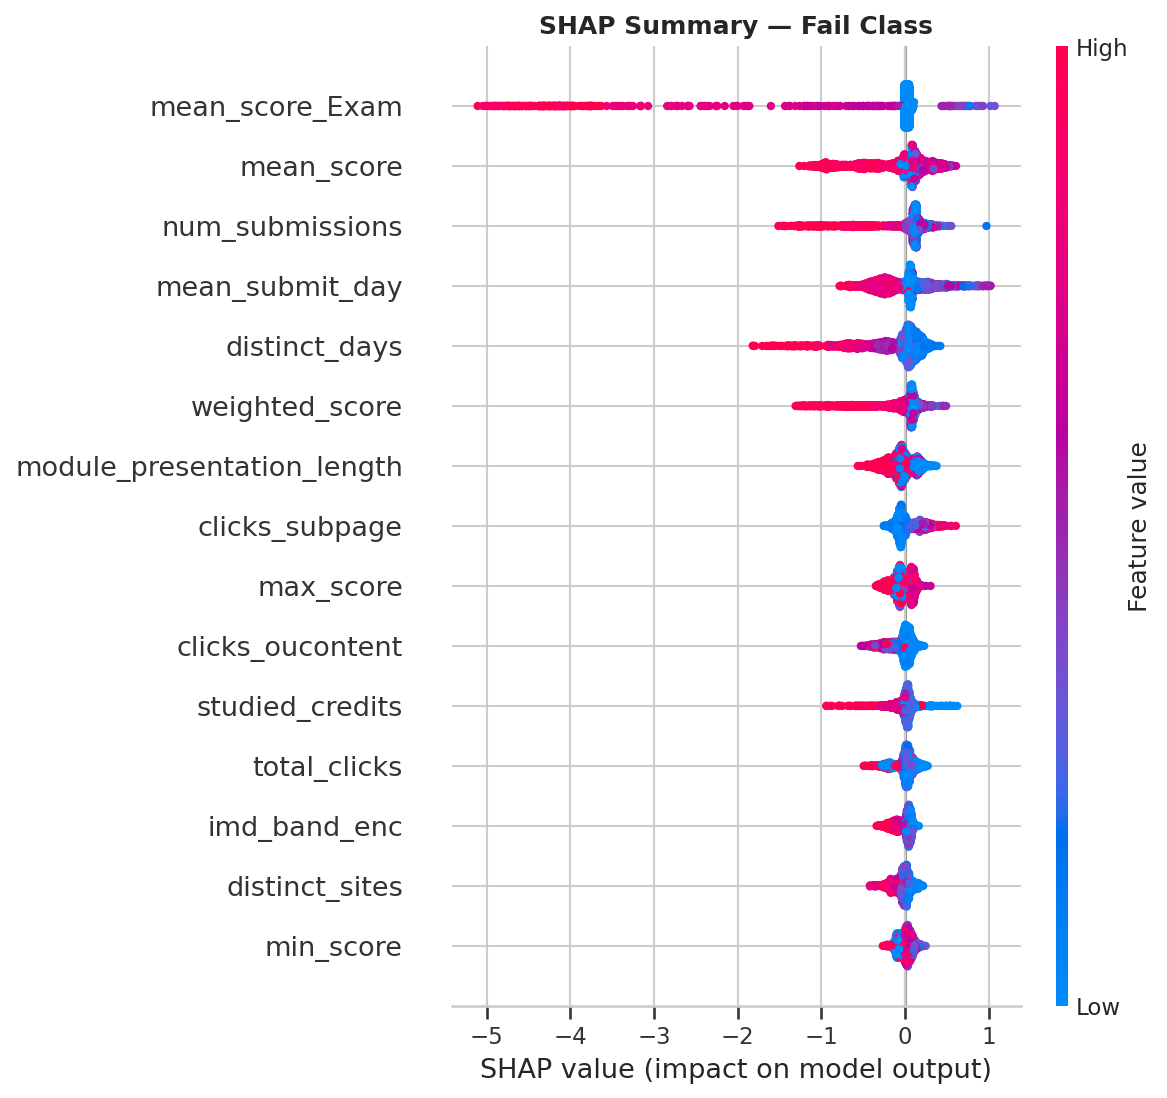

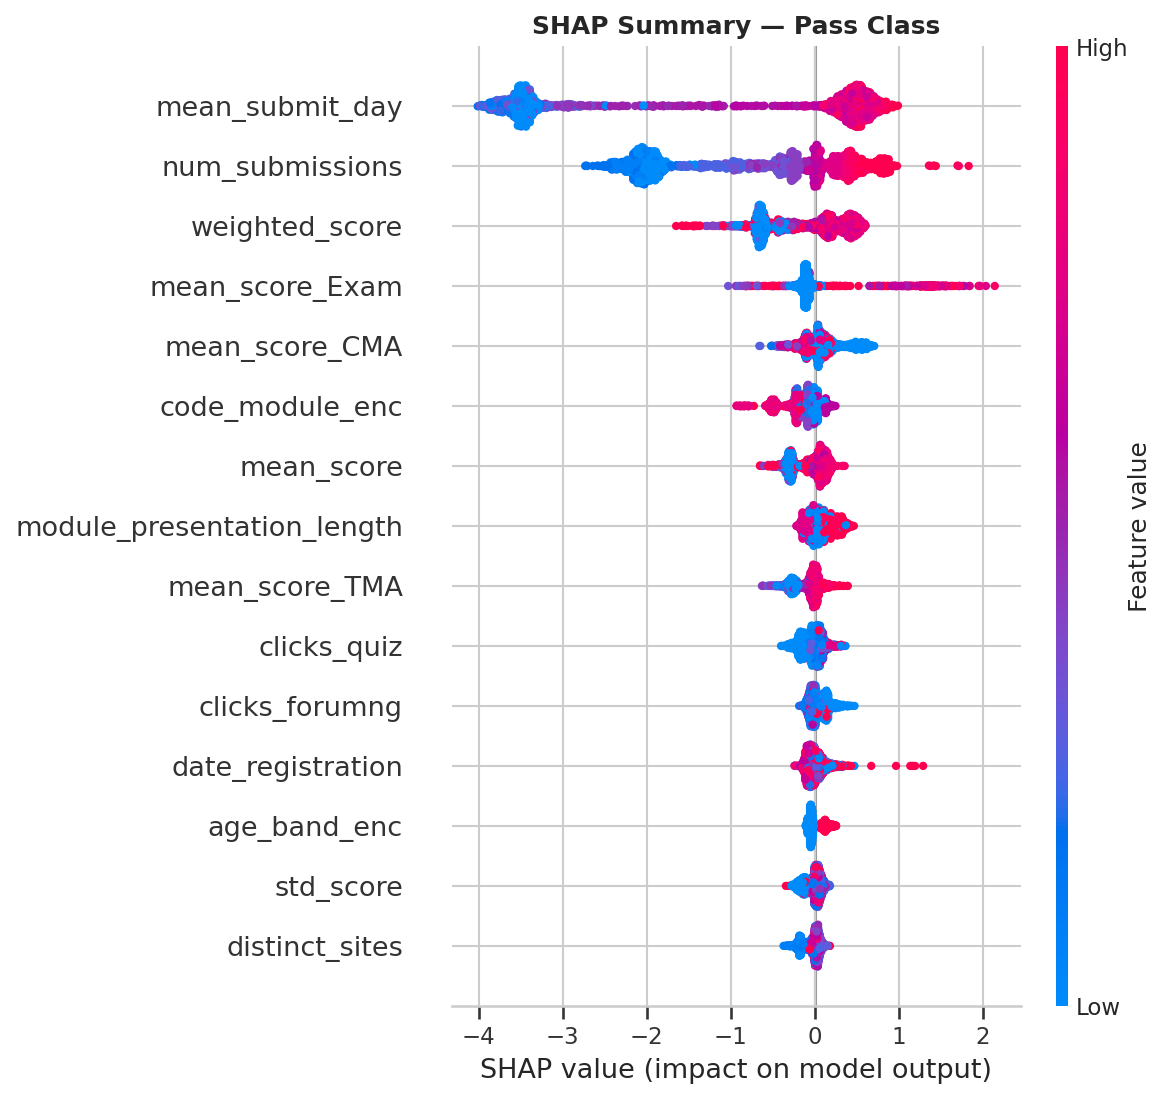

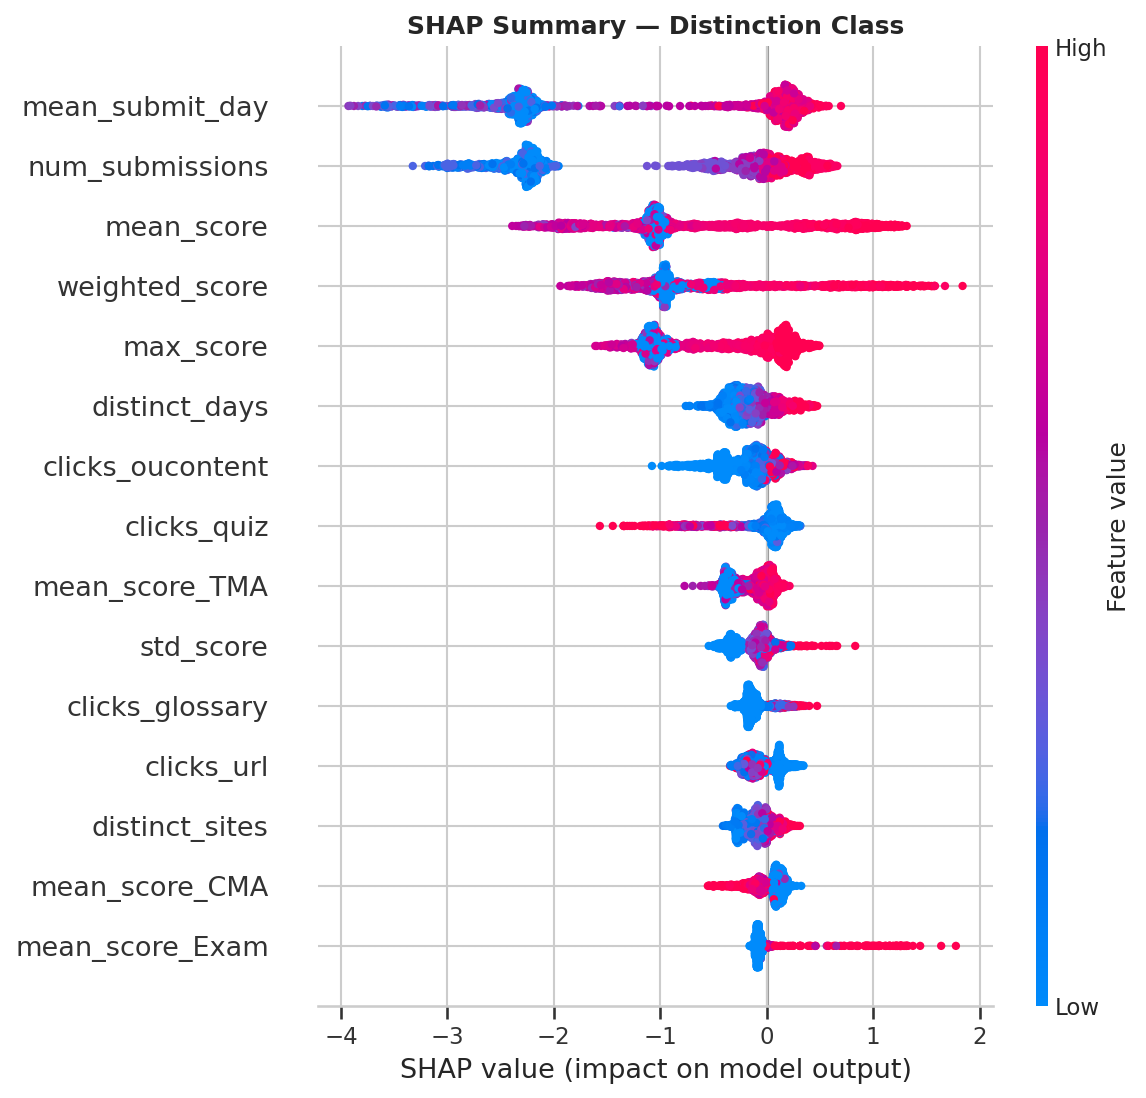

In [32]:
# Beeswarm for each class
if isinstance(shap_values, list):
    for cls_idx, cls_name in RESULT_NAMES.items():
        fig, ax = plt.subplots(figsize=(12, 8))
        shap.summary_plot(shap_values[cls_idx], X_shap, feature_names=FEATURES,
                          max_display=15, show=False)
        plt.title(f'SHAP Summary — {cls_name} Class', fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'shap_beeswarm_{cls_name.lower()}.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, max_display=15, show=False)
    plt.title('SHAP Summary (Beeswarm)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

print("SHAP beeswarm plots generated for all classes.")

## **Step 12 — SHAP Dependence Plots (Top Features)**

Dependence plots show how each feature value relates to the model output for the Fail class.
These can inform intervention thresholds (e.g., students below X clicks are at higher risk).


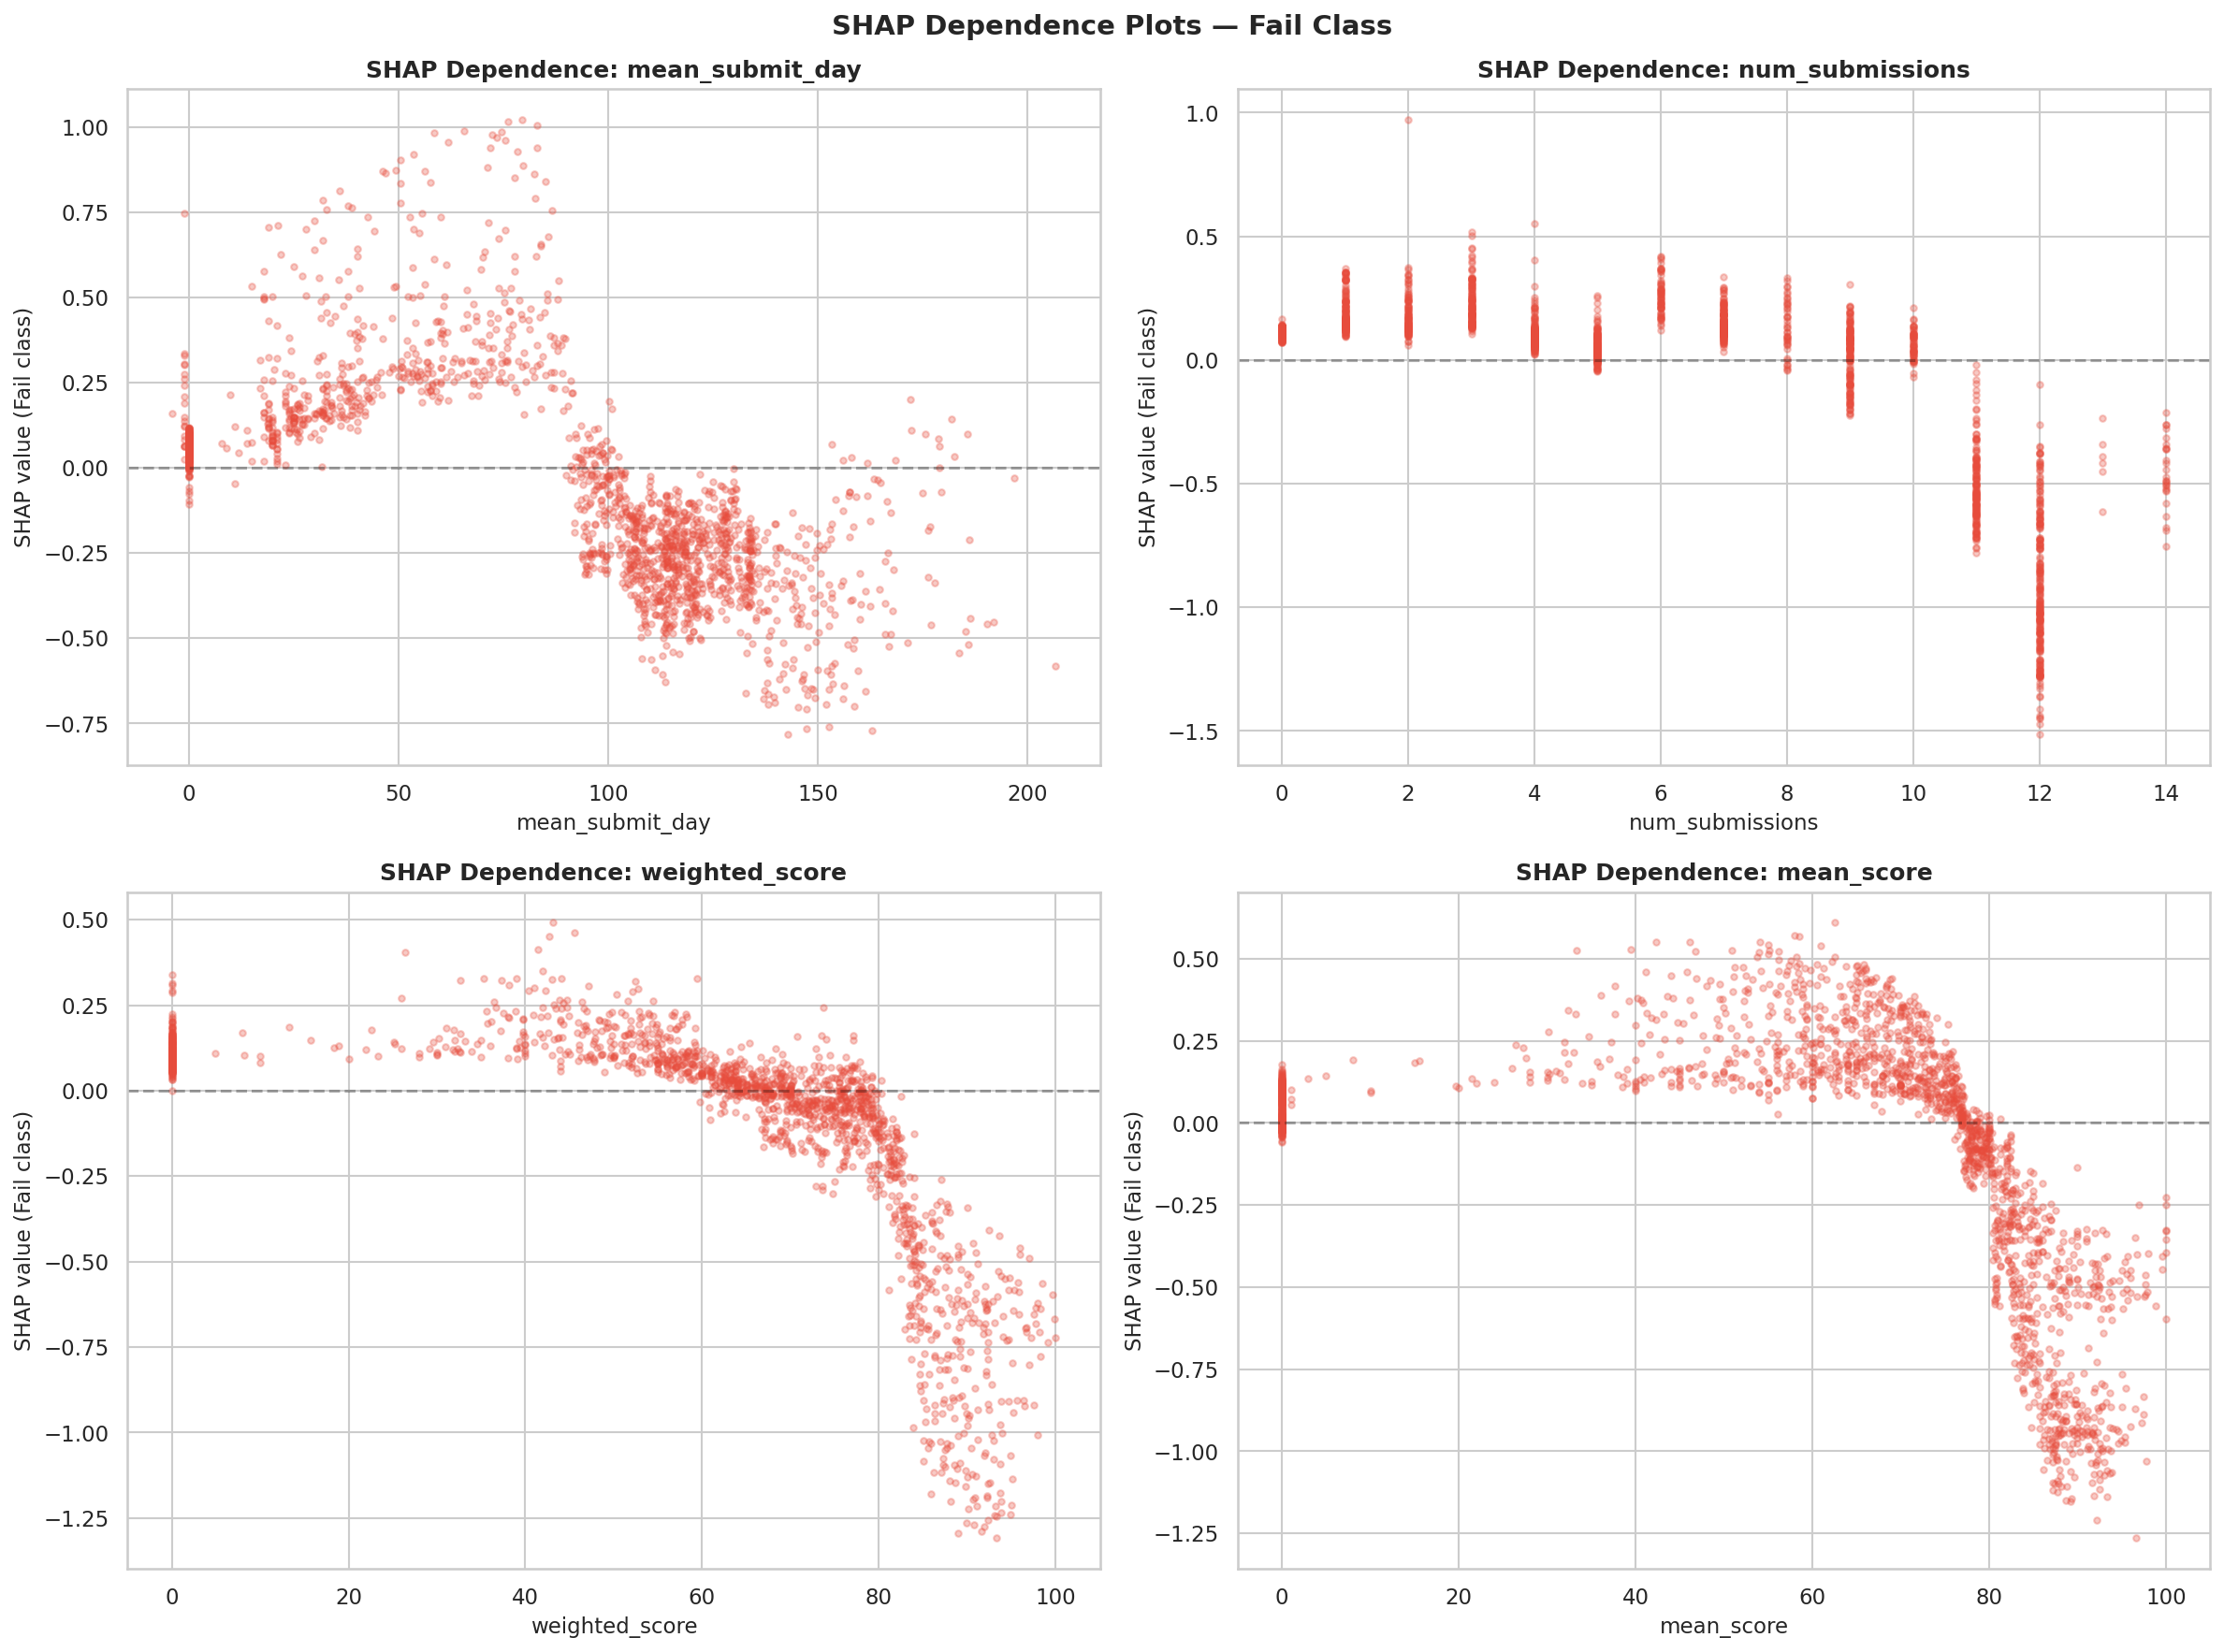

In [33]:
# Dependence plots for top 4 features
top4 = feat_importance.head(4)['feature'].tolist()

# Use SHAP values for the most important class (e.g., Fail=1 for intervention)
if isinstance(shap_values, list):
    shap_fail = shap_values[1]  # Fail class
else:
    shap_fail = shap_values

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, feat in enumerate(top4):
    ax = axes[i // 2][i % 2]
    feat_idx = FEATURES.index(feat)
    ax.scatter(X_shap[feat].values, shap_fail[:, feat_idx], alpha=0.3, s=10, c='#e74c3c')
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('SHAP value (Fail class)', fontsize=11)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.suptitle('SHAP Dependence Plots — Fail Class', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dependence plots show how each feature value relates to the model output for the Fail class.")
print("These can inform intervention thresholds (e.g., students below X clicks are at higher risk).")

## **Step 13 — SHAP Waterfall Plots (Individual Student Explanations)**

Fail student (index 7):

Distinction student (index 21):

Waterfall plots show exactly WHY a specific student received their prediction.
Educators can use these per-student explanations for targeted intervention.


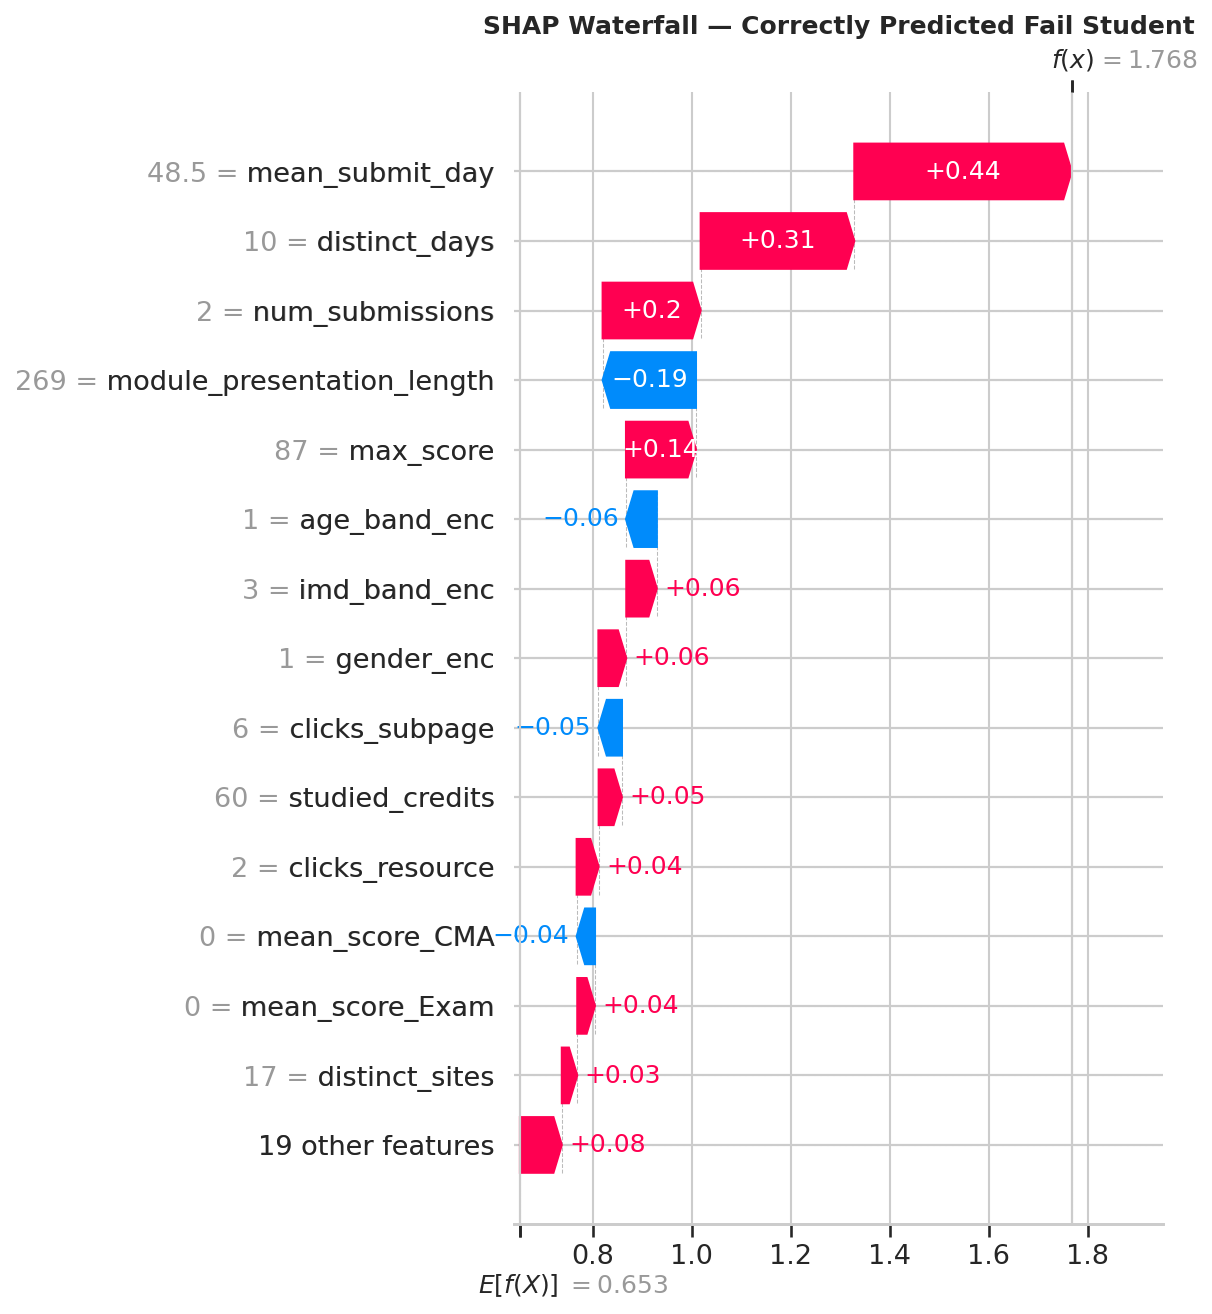

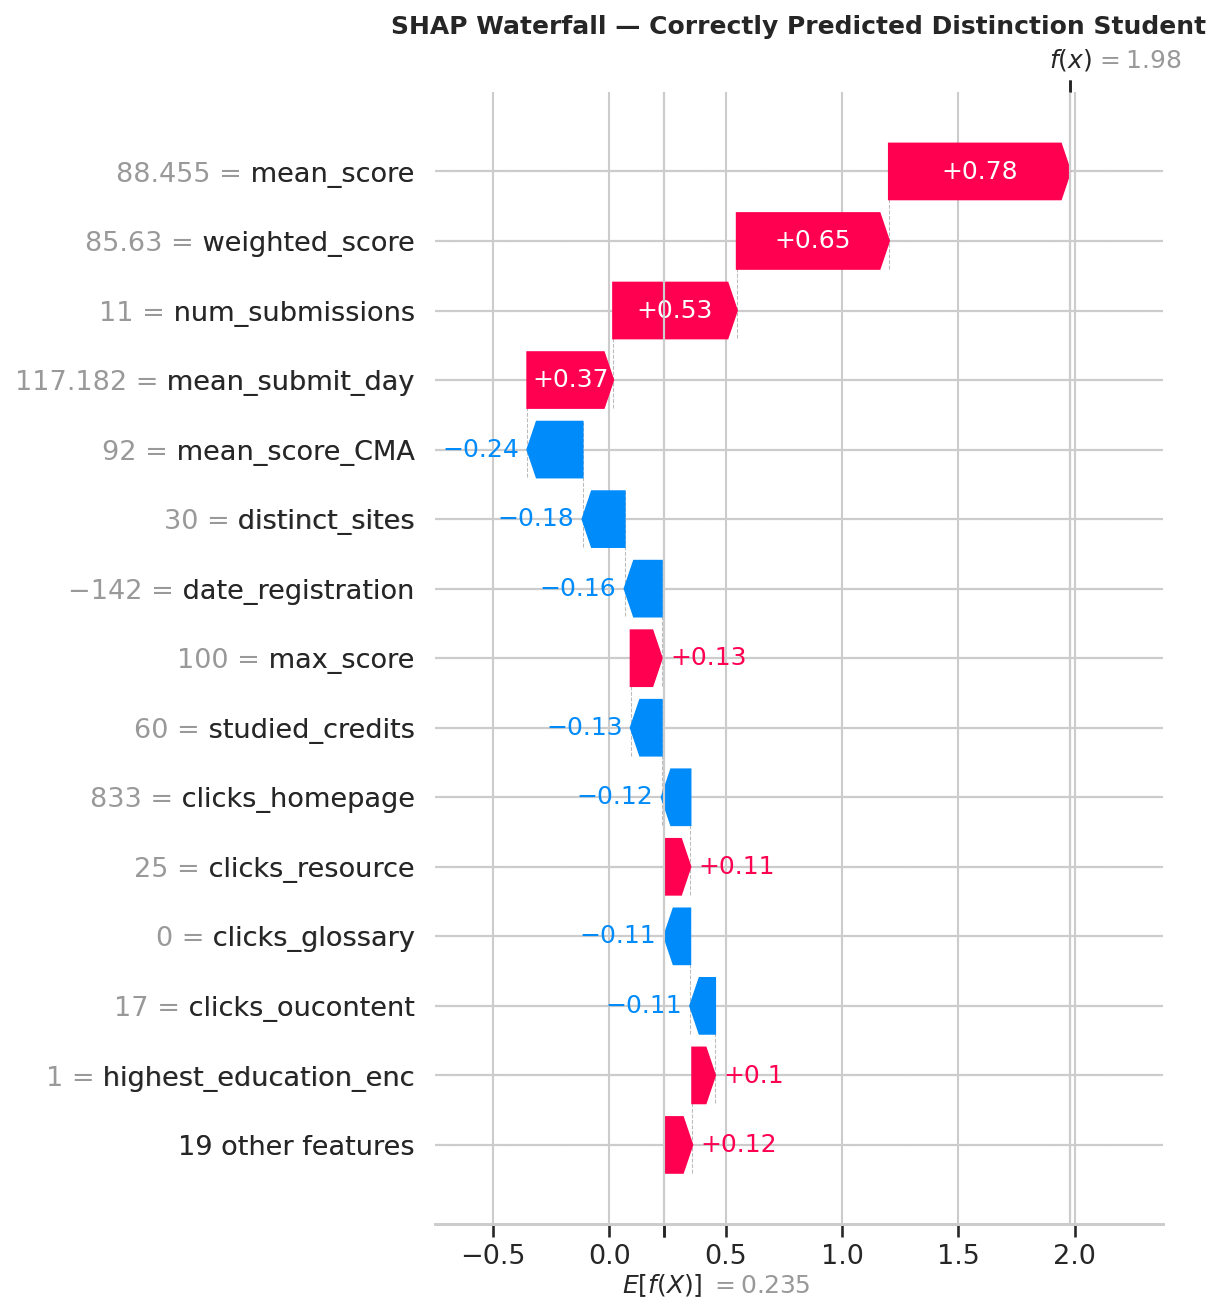

In [34]:
# Find a correctly predicted Fail student and a Distinction student
y_pred_shap = best_model.predict(X_shap)

fail_mask = (y_shap.values == 1) & (y_pred_shap == 1)
dist_mask = (y_shap.values == 3) & (y_pred_shap == 3)

# Get base values (expected values per class)
base_values = explainer.expected_value
if isinstance(base_values, np.ndarray) and base_values.ndim == 0:
    base_values = [float(base_values)] * 4  # scalar case

if fail_mask.sum() > 0:
    fail_idx = np.where(fail_mask)[0][0]
    print(f"Fail student (index {fail_idx}):")
    if isinstance(shap_values, list):
        sv_fail = shap_values[1][fail_idx]
        bv_fail = base_values[1] if hasattr(base_values, "__len__") else base_values
    else:
        sv_fail = shap_values[fail_idx]
        bv_fail = base_values
    exp = shap.Explanation(
        values=sv_fail,
        base_values=bv_fail,
        data=X_shap.iloc[fail_idx].values,
        feature_names=FEATURES
    )
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.title('SHAP Waterfall — Correctly Predicted Fail Student', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_fail.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No correctly predicted Fail students in sample.")

if dist_mask.sum() > 0:
    dist_idx = np.where(dist_mask)[0][0]
    print(f"\nDistinction student (index {dist_idx}):")
    if isinstance(shap_values, list):
        sv_dist = shap_values[3][dist_idx]
        bv_dist = base_values[3] if hasattr(base_values, "__len__") else base_values
    else:
        sv_dist = shap_values[dist_idx]
        bv_dist = base_values
    exp = shap.Explanation(
        values=sv_dist,
        base_values=bv_dist,
        data=X_shap.iloc[dist_idx].values,
        feature_names=FEATURES
    )
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.title('SHAP Waterfall — Correctly Predicted Distinction Student', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_distinction.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No correctly predicted Distinction students in sample.")

print("\nWaterfall plots show exactly WHY a specific student received their prediction.")
print("Educators can use these per-student explanations for targeted intervention.")


## **Step 14 — Temporal Validation (RQ3)**

Train on 2013 presentations (2013B + 2013J) and test on 2014 presentations (2014B + 2014J) to assess model generalisability across academic years.

In [35]:
# Temporal split: train on 2013, test on 2014
train_mask = df['code_presentation'].isin(['2013B', '2013J'])
test_mask = df['code_presentation'].isin(['2014B', '2014J'])

X_temporal_train = df.loc[train_mask, FEATURES].copy()
y_temporal_train = df.loc[train_mask, 'target'].copy()
X_temporal_test = df.loc[test_mask, FEATURES].copy()
y_temporal_test = df.loc[test_mask, 'target'].copy()

# Drop NaN
mask_tr = X_temporal_train.isnull().any(axis=1) | y_temporal_train.isnull()
mask_te = X_temporal_test.isnull().any(axis=1) | y_temporal_test.isnull()
X_temporal_train = X_temporal_train[~mask_tr]
y_temporal_train = y_temporal_train[~mask_tr]
X_temporal_test = X_temporal_test[~mask_te]
y_temporal_test = y_temporal_test[~mask_te]

print(f"Temporal train (2013): {X_temporal_train.shape}")
print(f"Temporal test (2014):  {X_temporal_test.shape}")
print(f"\nTrain target: {y_temporal_train.value_counts().sort_index().rename(RESULT_NAMES).to_dict()}")
print(f"Test target:  {y_temporal_test.value_counts().sort_index().rename(RESULT_NAMES).to_dict()}")

# Apply SMOTE to temporal training set
smote_temp = SMOTE(random_state=42)
X_temp_smote, y_temp_smote = smote_temp.fit_resample(X_temporal_train, y_temporal_train)

# Train all 3 models
temporal_results = {}
for name in ['Random Forest', 'XGBoost', 'LightGBM']:
    if name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5, random_state=42, n_jobs=-1)
    elif name == 'XGBoost':
        model = xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0)
    else:
        model = lgb.LGBMClassifier(n_estimators=300, max_depth=12, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, objective='multiclass', metric='multi_logloss', random_state=42, n_jobs=-1, verbose=-1)
    
    model.fit(X_temp_smote, y_temp_smote)
    y_pred_temp = model.predict(X_temporal_test)
    
    acc = accuracy_score(y_temporal_test, y_pred_temp)
    macro_f1 = f1_score(y_temporal_test, y_pred_temp, average='macro')
    
    temporal_results[name] = {'accuracy': acc, 'macro_f1': macro_f1, 'model': model, 'y_pred': y_pred_temp}
    print(f"  {name}: Accuracy={acc:.4f} | Macro-F1={macro_f1:.4f}")

print("\n=== Temporal vs Random Split Comparison (SMOTE) ===")
for name in temporal_results:
    random_f1 = smote_results[name]['macro_f1']
    temp_f1 = temporal_results[name]['macro_f1']
    degradation = (random_f1 - temp_f1) / random_f1 * 100
    print(f"  {name}: Random-F1={random_f1:.4f} | Temporal-F1={temp_f1:.4f} | Degradation={degradation:+.1f}%")

Temporal train (2013): (13529, 33)
Temporal test (2014):  (19064, 33)

Train target: {'Withdrawn': 3717, 'Fail': 3242, 'Pass': 5494, 'Distinction': 1076}
Test target:  {'Withdrawn': 6439, 'Fail': 3810, 'Pass': 6867, 'Distinction': 1948}
  Random Forest: Accuracy=0.7152 | Macro-F1=0.6955
  XGBoost: Accuracy=0.6685 | Macro-F1=0.6574
  LightGBM: Accuracy=0.6728 | Macro-F1=0.6589

=== Temporal vs Random Split Comparison (SMOTE) ===
  Random Forest: Random-F1=0.7133 | Temporal-F1=0.6955 | Degradation=+2.5%
  XGBoost: Random-F1=0.7169 | Temporal-F1=0.6574 | Degradation=+8.3%
  LightGBM: Random-F1=0.7159 | Temporal-F1=0.6589 | Degradation=+8.0%


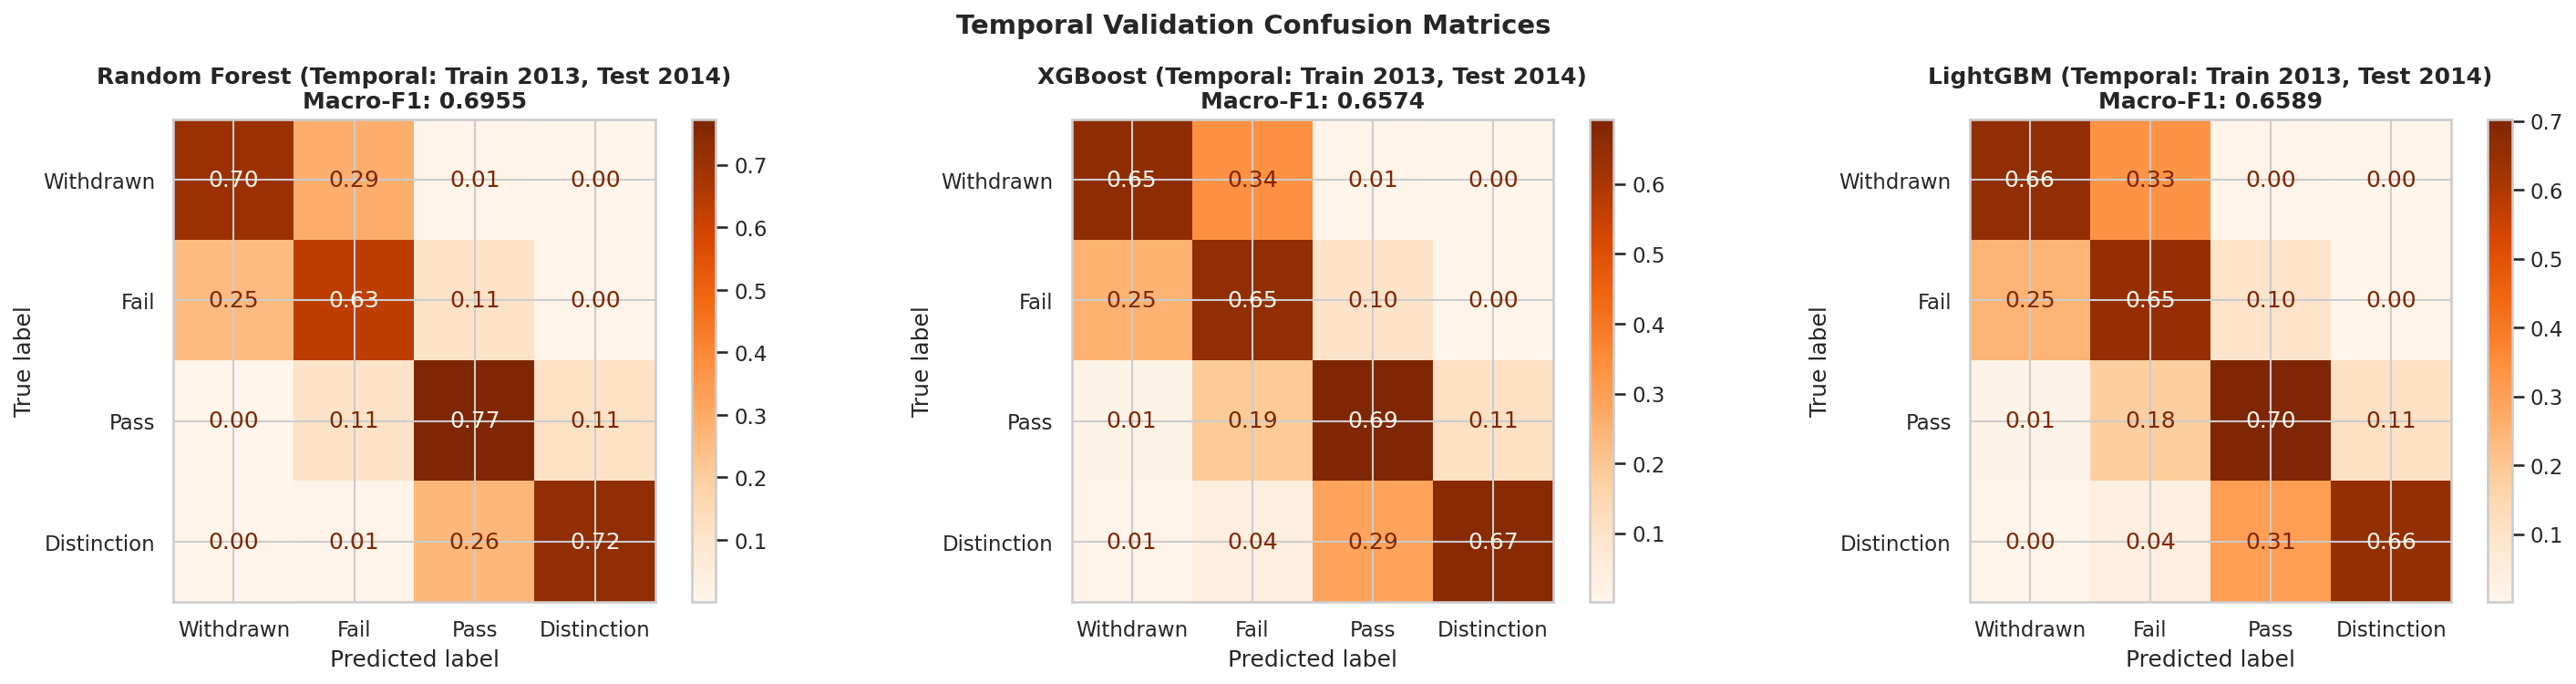

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, res) in enumerate(temporal_results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_temporal_test, res['y_pred'], display_labels=LABEL_NAMES, ax=axes[i],
        cmap='Oranges', normalize='true', values_format='.2f'
    )
    axes[i].set_title(f'{name} (Temporal: Train 2013, Test 2014)\nMacro-F1: {res["macro_f1"]:.4f}', fontweight='bold')

plt.suptitle('Temporal Validation Confusion Matrices', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('temporal_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 15 — Feature Importance Stability Across Cohorts (RQ3)**

Feature importance rank correlation (Spearman): rho=0.9632, p=0.000000
A high rho (>0.7) indicates features maintain consistent importance across cohorts.

Top 15 features — Random vs Temporal split:
          feature  rank_random  rank_temporal
  mean_submit_day            1              1
       mean_score            2              2
  num_submissions            3              3
   weighted_score            4              4
        max_score            5              6
   mean_score_TMA            6              5
    distinct_days            7              7
        min_score            8              9
        std_score            9              8
  clicks_homepage           10             10
  mean_score_Exam           11             22
     total_clicks           12             11
   distinct_sites           13             14
      clicks_quiz           14             12
date_registration           15             13


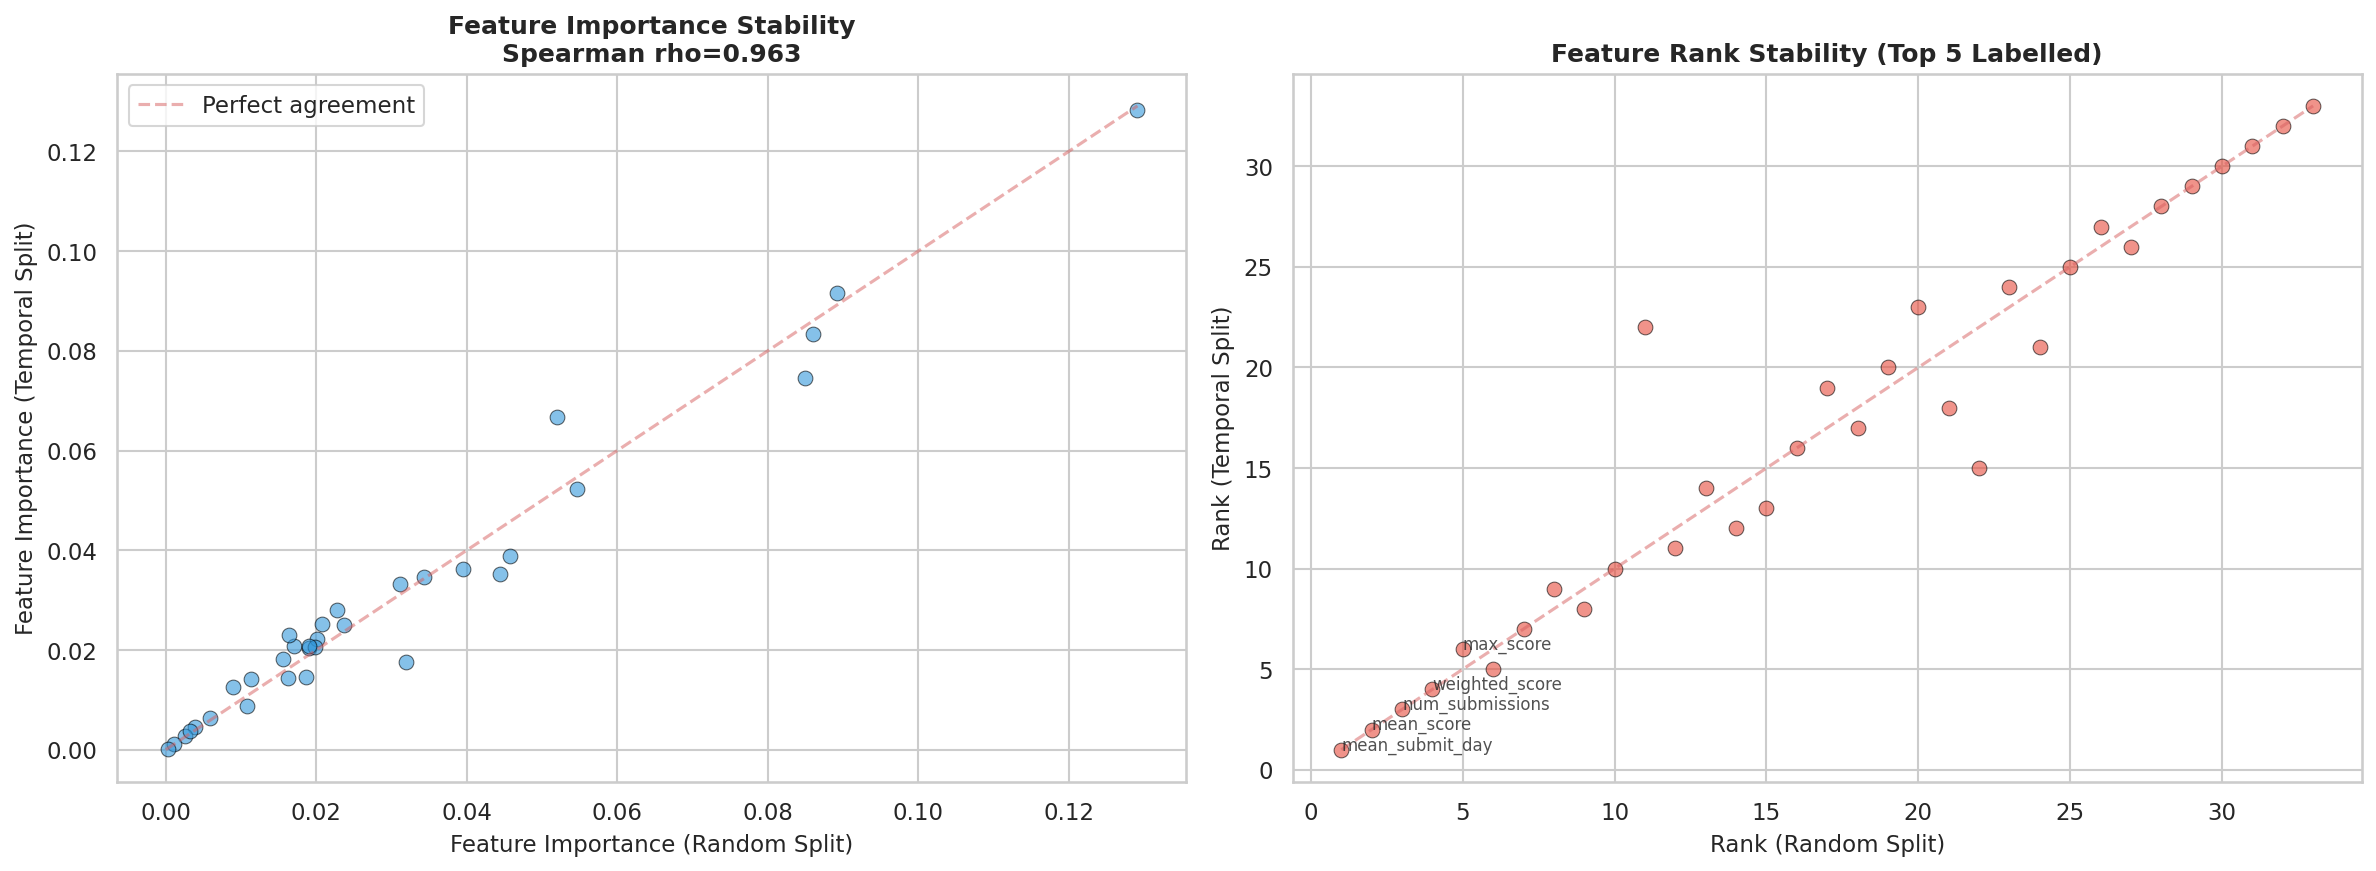

In [37]:
# spearmanr is already imported in the unified imports cell at the top

# Get feature importance from random split model and temporal model
# Use the best model type from the temporal run
best_temp_name = max(temporal_results, key=lambda k: temporal_results[k]['macro_f1'])
temporal_model = temporal_results[best_temp_name]['model']
random_model = smote_results[best_temp_name]['model']

# Extract feature importances
if hasattr(random_model, 'feature_importances_'):
    imp_random = random_model.feature_importances_
    imp_temporal = temporal_model.feature_importances_
else:
    imp_random = np.zeros(len(FEATURES))
    imp_temporal = np.zeros(len(FEATURES))

# Rank correlation
rank_corr, p_value = spearmanr(imp_random, imp_temporal)
print(f"Feature importance rank correlation (Spearman): rho={rank_corr:.4f}, p={p_value:.6f}")
print(f"A high rho (>0.7) indicates features maintain consistent importance across cohorts.\n")

# Compare top 10 features
imp_df = pd.DataFrame({
    'feature': FEATURES,
    'importance_random': imp_random,
    'importance_temporal': imp_temporal,
    'rank_random': pd.Series(imp_random).rank(ascending=False).astype(int),
    'rank_temporal': pd.Series(imp_temporal).rank(ascending=False).astype(int)
}).sort_values('importance_random', ascending=False)

print("Top 15 features — Random vs Temporal split:")
print(imp_df.head(15)[['feature', 'rank_random', 'rank_temporal']].to_string(index=False))

# Scatter plot of ranks
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Importance comparison
axes[0].scatter(imp_random, imp_temporal, alpha=0.6, s=50, c='#3498db', edgecolors='black', linewidth=0.5)
max_val = max(imp_random.max(), imp_temporal.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Perfect agreement')
axes[0].set_xlabel('Feature Importance (Random Split)', fontsize=11)
axes[0].set_ylabel('Feature Importance (Temporal Split)', fontsize=11)
axes[0].set_title(f'Feature Importance Stability\nSpearman rho={rank_corr:.3f}', fontweight='bold')
axes[0].legend()

# Rank comparison
axes[1].scatter(imp_df['rank_random'], imp_df['rank_temporal'], alpha=0.6, s=50, c='#e74c3c', edgecolors='black', linewidth=0.5)
axes[1].plot([1, len(FEATURES)], [1, len(FEATURES)], 'r--', alpha=0.5)
for _, row in imp_df.head(5).iterrows():
    axes[1].annotate(row['feature'], (row['rank_random'], row['rank_temporal']),
                     fontsize=8, alpha=0.8)
axes[1].set_xlabel('Rank (Random Split)', fontsize=11)
axes[1].set_ylabel('Rank (Temporal Split)', fontsize=11)
axes[1].set_title('Feature Rank Stability (Top 5 Labelled)', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_stability.png', dpi=150, bbox_inches='tight')
plt.show()